In [2]:
import numpy as np
import pandas as pd
import sklearn.model_selection
import argparse, os, glob, re, warnings, shutil, pysam, vcf, subprocess
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from Bio import Seq, SeqIO
import scipy.stats as st

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv")

df_assemblies = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) == float:
            df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
        else:
            df_trust_patients.loc[i, 'Lineage'] = str(row['Lineage'])
     
print(df_trust_patients.Lineage.value_counts())
            
F2_max = 0.03

mixed_lineage_samples = df_trust_patients.query("F2 > @F2_max").SampleID.unique()
unmixed_lineage_samples = df_trust_patients.query("F2 <= @F2_max").SampleID.unique()

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
    
# exclude any indel within 100 bp of an insertion seq / phage and also within those regions
insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    
    insertion_seqs_phages_pos += list(np.arange(row['Start'] - 100, row['Stop'] + 100 + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)
len(insertion_seqs_phages_pos)

def get_id_from_gtf_attribute(attr_string):
    """
    Extract the value of the ID field from a GTF/GFF attributes string.

    Example:
    attr_string = "ID=gene-Rv3324c;Dbxref=GeneID:887981;Name=moaC3;..."
    returns "gene-Rv3324c"
    """
    # Split by semicolon
    fields = attr_string.split(";")
    
    # Iterate through key=value pairs
    for f in fields:
        f = f.strip()
        if f.startswith("ID="):
            return f.split("=", 1)[1]  # split only on first '='
    
    # If no ID field found, return None
    return None


Lineage
2      384
4      332
3       48
2,4      6
1        1
2,3      1
Name: count, dtype: int64
rrs
rrl
rrf


# Forest plot for the linear mixed model

In [15]:
model_dir = "unmixed_only"
linear_mixed_model = pd.read_csv(f"{model_dir}/linear_mixed_model_summary.csv").rename(columns={'term': 'covariate', 'p.value': 'pval', 'conf.low': 'estimate_lower', 'conf.high': 'estimate_upper'})

In [23]:
def forest_plot(df, labels_dict, val_col='OR', alpha=0.05, log=False, pval_offset=1.05, df_stratify_variables_results=None, saveName=None):
    
    # add the relative risks dataframe to plot those as well
    if df_stratify_variables_results is not None:
        df = pd.concat([df, df_stratify_variables_results])
    
    # Filter out the intercept and add a "significant" column if it doesn't exist
    df = df.query("covariate != 'intercept'")

    df.loc[df['pval'] <= alpha, 'significant'] = 1
    df['significant'] = df['significant'].fillna(0).astype(int)

    # improve the names for tick labels
    df['plot_column'] = df['covariate'].map(labels_dict)

    if sum(pd.isnull(df['plot_column'])) > 0:
        raise ValueError(f"{df.loc[pd.isnull(df['plot_column'])].covariate.values} don't have label mappings")
    
    # Sort by significance and value
    df = df.sort_values(["significant", val_col], ascending=[False, False]).reset_index(drop=True)

    df.loc[df['significant']==1, 'point_color'] = 'darkorange'
    df.loc[df['significant']==1, 'err_color'] = 'darkorange'
    df.loc[df['significant']==0, 'point_color'] = 'black'
    df.loc[df['significant']==0, 'err_color'] = 'gray'
            
    # Separate significant and non-significant predictors
    significant_df = df.query("significant==1")
    non_significant_df = df.query("significant==0")
    
    conf_lower_col = f"{val_col}_lower"
    conf_upper_col = f"{val_col}_upper"

    # Plotting
    fig, ax = plt.subplots(figsize=(6, len(df) * 0.6))

    conf_lower_col = f"{val_col}_lower"
    conf_upper_col = f"{val_col}_upper"
    
    def format_sigfig_fixed(x, sig=2):
        if x == 0:
            return 0.00
        elif x < 0.01:
            # return these in scientific notation because they are so small
            return "{:.1e}".format(x)
        elif x < 0.1:
            return np.round(x, 2)
        else:
            # Determine how many decimal places to show
            digits = sig - int(np.floor(np.log10(abs(x)))) - 1
            if digits < 0:
                # Round to nearest 10s, 100s, etc.
                rounded = round(x, digits)
                return f"{rounded:.0f}"
            else:
                return f"{x:.{digits}f}"
    
        # digits = sig - int(np.floor(np.log10(abs(x)))) - 1
        # return f"{round(x, digits):f}".rstrip('0').rstrip('.')  # strip trailing 0s and .

    for i, row in df.iterrows():
    
        # Plot significant predictors in orange
        ax.errorbar(
            row[val_col], 
            i,
            xerr = [[row[val_col] - row[conf_lower_col]],
                    [row[conf_upper_col] - row[val_col]]],
            fmt='o', color=row['point_color'], ecolor=row['err_color'], markeredgewidth=0.7, markeredgecolor='black', capsize=3
        )

        ax.text(df[conf_upper_col].max() * pval_offset, i + 0.1, f"p = {format_sigfig_fixed(row['pval'])}")

    # Customize plot appearance
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["plot_column"], fontsize=11)
    
    if 'HR' in val_col:
        ax.set_xlabel("Hazard Ratio for Longer TCC")
    else:
        ax.set_xlabel("Hazard Ratio")
    
    # Add a vertical reference line at OR = 1
    ax.axvline(x=1.0, color='red', linestyle='--', lw=0.75, zorder=0)
    
    sns.despine()
    plt.gca().invert_yaxis()
    
    # Show legend
    # ax.legend()
    
    if log:
        plt.xscale('log', base=10)
        
        # change the tick labels from 10^0 to 1
        ax.set_xticks(ax.get_xticks(), [format_sigfig_fixed(val) for val in ax.get_xticks()])

    # Show or save the plot
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')
        plt.close()

In [24]:
linear_mixed_model

,effect,covariate,estimate,std.error,statistic,pval,estimate_lower,estimate_upper
0,fixed,(Intercept),1.077169e-19,6.029170e-19,-7.802917,6.049249e-15,1.853132e-24,6.261253e-15
1,fixed,COV_RATIO,3.403918e+00,1.799658e+00,2.316859,2.051142e-02,1.207668e+00,9.594246e+00
2,fixed,CLIPPED_BASES_RATIO,1.380389e-102,4.229309e-101,-7.655112,1.931441e-14,1.149329e-128,1.657902e-76
3,fixed,DISCORDANT_READS_RATIO,3.739241e-04,4.650877e-04,-6.344623,2.229714e-10,3.266305e-05,4.280654e-03
4,fixed,Mean_BQ_ALT_allele,2.645718e+00,1.016093e+00,2.533361,1.129746e-02,1.246344e+00,5.616285e+00
5,fixed,SAF_prop_deviation_from_half,4.644990e-01,1.596352e-01,-2.231187,2.566877e-02,2.368377e-01,9.110007e-01


In [27]:
labels_dict = {'COV_RATIO': 'Coverage Ratio', 'CLIPPED_BASES_RATIO': 'Clipped Bases', 'DISCORDANT_READS_RATIO': 'Discordant Reads',
               'Mean_BQ_ALT_allele': 'Average Base Quality', 'SAF_prop_deviation_from_half': 'Deviation from 50% Forward Reads'
              }

forest_plot(linear_mixed_model.query("~covariate.str.contains('intercept', case=False)"), labels_dict, val_col='estimate', saveName=f"{model_dir}/forest_plot_python.svg")

# Get a list of sites that were False in all Ground Truth Samples or Predicted False

## How much do these overlap with different lineage barcodes?

## Send a list to TRUST / BioSensor channel. For the predicted False ones, include the probability predictions

In [11]:
ground_truth_samples = os.listdir(personal_ref_dir)

In [35]:
df_figtree_color = df_trust_patients.query("F2 <= @F2_max")[['SampleID', 'Lineage']]
df_figtree_color['Lineage'] = df_figtree_color['Lineage'].astype(int)
len(df_figtree_color)
df_figtree_color[['SampleID', 'Lineage']].to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/samples_lineage_annot.tsv", sep='\t', index=False)

In [6]:
L3_samples_with_dup = np.concatenate([df_train.query("POS >= 2338129 & POS <= 2340759 & Lineage in [3, '3']").SampleID.unique(),
                                 df_val.query("POS >= 2338129 & POS <= 2340759 & Lineage in [3, '3']").SampleID.unique()
                                ])

L3_samples = np.concatenate([df_train.query("Lineage in [3, '3']").SampleID.unique(),
                                 df_val.query("Lineage in [3, '3']").SampleID.unique()
                                ])

set(L3_samples) - set(L3_samples_with_dup)

set()

In [8]:
df_trust_patients.query("Lineage in [4, '4']").Coll2014.value_counts()

Coll2014
4.3.2.1              61
4.1.1.1              57
4.3.3                43
4.4.1.1              37
4.1.1.3              34
4.8                  31
4.3.4.2.1            21
4.1.2.1              15
4.1.2                 8
4.3.4.1               7
4.1.1.2               4
4.7                   3
4.9                   2
4.1                   2
4.3.2                 2
4.1.2.1,4.8           2
4.2.2                 2
4.3.4.2.1,4.1.1.1     1
Name: count, dtype: int64

In [15]:
search_samples = np.concatenate([df_train.query("POS >= 2338129 & POS <= 2340759 & Lineage not in [3, '3']").SampleID.unique(),
                                 df_val.query("POS >= 2338129 & POS <= 2340759 & Lineage not in [3, '3']").SampleID.unique()
                                ])

L4_lineages_with_dup = df_trust_patients.query("SampleID in @search_samples")[['pid', 'SampleID', 'Coll2014', 'F2']].Coll2014.unique()
print(L4_lineages_with_dup)

df_trust_patients.query("Coll2014 in @L4_lineages_with_dup & SampleID not in @search_samples")

['4.1.2' '4.1.1.2' '4.2.2']


,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week


In [57]:
df_Coll.query("position in [2339240, 2339255]")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp,Coll2014
1924,lineage3,2339240,532,G/A,178,GGT/AGT,G/S,Rv2082,0,nonsyn,nonessential,no,3


In [19]:
df_Coll.query("Coll2014 in @L4_lineages_with_dup & position >= 2338129 & position <= 2340759")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp,Coll2014


In [22]:
df_Coll.query("Coll2014 in @L4_lineages_with_dup & position >= 2338065 & position <= 2340874")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp,Coll2014


In [32]:
Rv2082_lineage_pos = df_Coll.query("locus_Id=='Rv2082' & Coll2014.str.startswith('4')").position.values

In [39]:
df_Coll.query("locus_Id=='Rv2082' & Coll2014.str.startswith('4')")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp,Coll2014
3245,lineage4.2.2.1,2338768,60,G/T,20,CCG/CCT,P/P,Rv2082,0,syn,nonessential,no,4.2.2.1
3246,lineage4.2.2.1,2338773,65,G/A,22,CGG/CAG,R/Q,Rv2082,0,nonsyn,nonessential,no,4.2.2.1
3247,lineage4.2.2.1,2338912,204,A/C,68,CGA/CGC,R/R,Rv2082,0,syn,nonessential,no,4.2.2.1
4691,lineage4.6.2,2340797,2089,A/G,697,ATC/GTC,I/V,Rv2082,0,nonsyn,nonessential,no,4.6.2
5024,lineage4.6.2.2,2340097,1389,C/T,463,GGC/GGT,G/G,Rv2082,0,syn,nonessential,no,4.6.2.2


In [7]:
df_Coll.query("position >= 2338065 & position <= 2340874 & Coll2014.str.startswith('4')")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp,Coll2014
3245,lineage4.2.2.1,2338768,60,G/T,20,CCG/CCT,P/P,Rv2082,0,syn,nonessential,no,4.2.2.1
3246,lineage4.2.2.1,2338773,65,G/A,22,CGG/CAG,R/Q,Rv2082,0,nonsyn,nonessential,no,4.2.2.1
3247,lineage4.2.2.1,2338912,204,A/C,68,CGA/CGC,R/R,Rv2082,0,syn,nonessential,no,4.2.2.1
4691,lineage4.6.2,2340797,2089,A/G,697,ATC/GTC,I/V,Rv2082,0,nonsyn,nonessential,no,4.6.2
5024,lineage4.6.2.2,2340097,1389,C/T,463,GGC/GGT,G/G,Rv2082,0,syn,nonessential,no,4.6.2.2


In [45]:
df_Coll.query("Coll2014=='4.2.2.1' & diagnostic_snp=='yes'")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp,Coll2014
3194,lineage4.2.2.1,1131,1131,C/A,377,ATC/ATA,I/I,Rv0001,dnaA,syn,essential,yes,4.2.2.1
3224,lineage4.2.2.1,1455780,286,T/C,96,TTG/CTG,L/L,Rv1299,prfA,syn,essential,yes,4.2.2.1


In [46]:
df_Coll.query("Coll2014.str.startswith('3')  & diagnostic_snp=='yes'")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp,Coll2014
1806,lineage3,301341,315,C/A,105,CCG/CCT,P/P,Rv0249c,0,syn,essential,yes,3
1810,lineage3,342873,744,C/T,248,GTC/GTT,V/V,Rv0282,eccA3,syn,essential,yes,3
1830,lineage3,652950,180,T/C,60,CGT/CGC,R/R,Rv0562,grcC1,syn,essential,yes,3
1890,lineage3,1812448,90,C/T,30,TAC/TAT,Y/Y,Rv1613,trpA,syn,essential,yes,3
1949,lineage3,2782498,1545,G/A,515,GAC/GAT,D/D,Rv2477c,0,syn,essential,yes,3
1959,lineage3,2941179,18,G/A,6,CGC/CGT,R/R,Rv2613c,0,syn,essential,yes,3
1974,lineage3,3165807,603,G/A,201,GTG/GTA,V/V,Rv2855,mtr,syn,essential,yes,3
1983,lineage3,3273107,894,C/A,298,GCC/GCA,A/A,Rv2936,drrA,syn,essential,yes,3
2014,lineage3,3918649,552,T/C,184,GGA/GGG,G/G,Rv3499c,mce4A,syn,essential,yes,3
2062,lineage3.1.1,1084911,840,G/A,280,TAC/TAT,Y/Y,Rv0973c,accA2,syn,essential,yes,3.1.1


In [21]:
df_Coll.query("Coll2014 in @L4_lineages_with_dup")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp,Coll2014
2657,lineage4.1.1.2,112737,2737,G/A,913,GAC/AAC,D/N,Rv0101,nrp,nonsyn,essential,no,4.1.1.2
2658,lineage4.1.1.2,154671,440,G/A,147,AGT/AAT,S/N,Rv0127,mak,nonsyn,essential,no,4.1.1.2
2659,lineage4.1.1.2,256830,767,C/T,256,ACC/ATC,T/I,Rv0214,fadD4,nonsyn,nonessential,no,4.1.1.2
2660,lineage4.1.1.2,266115,609,C/T,203,GCC/GCT,A/A,Rv0222,echA1,syn,ND,no,4.1.1.2
2661,lineage4.1.1.2,274930,57,G/A,19,GGC/GGT,G/G,Rv0229c,0,syn,nonessential,no,4.1.1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3189,lineage4.2.2,3635110,1158,G/A,386,GCC/GCT,A/A,Rv3255c,manA,syn,essential,no,4.2.2
3190,lineage4.2.2,3744931,8254,C/A,2752,GCC/TCC,A/S,Rv3347c,PPE55,nonsyn,ND,no,4.2.2
3191,lineage4.2.2,4168330,0,G/A,0,./.,./.,0,0,inter,0,no,4.2.2
3192,lineage4.2.2,4324358,344,T/C,115,ATC/ACC,I/T,Rv3850,0,nonsyn,nonessential,no,4.2.2


In [20]:
2340759-2338129

2630

In [70]:
df_trust_patients.query("SampleID in @search_samples | SampleID in ['MFS-588', 'MFS-589']")[['pid', 'SampleID', 'Coll2014', 'F2', 'bl_household', 'bl_housecode', 'bl_houseclose', 'bl_houseclosenum',
       'bl_houseclose_1code', 'bl_houseclose_1type', 'bl_houseclose_2code',
       'bl_houseclose_2type']]

,pid,SampleID,Coll2014,F2,bl_household,bl_housecode,bl_houseclose,bl_houseclosenum,bl_houseclose_1code,bl_houseclose_1type,bl_houseclose_2code,bl_houseclose_2type
102,T0076,MFS-731,4.1.2,0.020352,0,NaN,0,NaN,NaN,NaN,NaN,NaN
103,T0076,MFS-559,4.1.2,0.021138,0,NaN,0,NaN,NaN,NaN,NaN,NaN
120,T0137,MFS-746,4.1.2,0.020100,0,NaN,0,NaN,NaN,NaN,NaN,NaN
121,T0137,MFS-600,4.1.2,0.018452,0,NaN,0,NaN,NaN,NaN,NaN,NaN
228,T0436,MFS-818,4.1.2,0.025057,0,NaN,0,NaN,NaN,NaN,NaN,NaN
229,T0436,MFS-701,4.1.2,0.025379,0,NaN,0,NaN,NaN,NaN,NaN,NaN
252,T0455,MFS-833,4.1.1.2,0.022982,0,NaN,0,NaN,NaN,NaN,NaN,NaN
253,T0455,MFS-716,4.1.1.2,0.019856,0,NaN,0,NaN,NaN,NaN,NaN,NaN
355,T0125,MFS-588,4.1,0.023414,0,NaN,0,NaN,NaN,NaN,NaN,NaN
356,T0125,MFS-589,4.1,0.020902,0,NaN,0,NaN,NaN,NaN,NaN,NaN


In [66]:
df_trust_patients.columns[df_trust_patients.columns.str.contains('bl_house')]

Index(['bl_household', 'bl_housecode', 'bl_houseclose', 'bl_houseclosenum',
       'bl_houseclose_1code', 'bl_houseclose_1type', 'bl_houseclose_2code',
       'bl_houseclose_2type'],
      dtype='object')

In [65]:
df_figtree_color.loc[df_figtree_color['SampleID'].isin(search_samples), 'Lineage'] = '4 DUP'
df_figtree_color[['SampleID', 'Lineage']].to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/samples_lineage_annot.tsv", sep='\t', index=False)

In [36]:
df_figtree_color.Lineage.value_counts()

Lineage
2    369
4    324
3     48
1      1
Name: count, dtype: int64

In [22]:
df_figtree_color.query("SampleID=='MFS-741'")

,SampleID,Lineage
116,MFS-741,4


In [5]:
model_dir = "unmixed_only"

df_train = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")
df_val = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")

Coll_sites = pd.read_csv("~/Mtb_Megapipe/references/phylogeny/Coll2014_positions_all.txt", sep='\t', header=None)[1].values
df_Coll = pd.read_csv("~/Mtb_Megapipe/references/phylogeny/Coll2014_SNPs_all.csv")

df_Coll['Coll2014'] = df_Coll['lineage'].str.replace('lineage', '')

In [42]:
df_val.query("GENE=='sugI'").pred_class.value_counts()

pred_class
1    34
0     2
Name: count, dtype: int64

In [49]:
df_val.query("GENE=='sugI' & SampleID=='MFS-474'")#' & pred_class==0")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,SampleID,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,False_in_all_Ground_Truth_Samples,predicted,pred_class
1132,3717219,C,A,0.000000e+00,NaN,sugI,c.130C>A,p.Leu44Met,1,303,...,MFS-474,T0380,2.2.1,2.2.1.1.1,2,0.008621,0.100000,0,0.993507,1
1133,3717226,G,T,9.400000e-14,NaN,sugI,c.137_138delGAinsTG,p.Arg46Met,1,290,...,MFS-474,T0380,2.2.1,2.2.1.1.1,2,0.008621,0.151515,0,0.171859,0
1134,3717227,A,G,9.400000e-14,NaN,sugI,c.137_138delGAinsTG,p.Arg46Met,1,290,...,MFS-474,T0380,2.2.1,2.2.1.1.1,2,0.008621,0.151515,0,0.212192,0


In [41]:
min_pos = df_train.query("Real==1").POS.min()
max_pos = df_train.query("Real==1").POS.max()
AF_max = 0.9

exclude_pos = np.sort(list(set(df_train.query("POS >= @min_pos & POS <= @max_pos & AF <= @AF_max & False_in_all_Ground_Truth_Samples==1").POS).union(df_val.query("POS >= @min_pos & POS <= @max_pos & AF <= @AF_max & False_in_all_Ground_Truth_Samples==1").POS).union(df_val.query("POS >= @min_pos & POS <= @max_pos & AF <= @AF_max & pred_class==0").POS)))
# exclude_pos = np.sort(list(set(df_train.query("AF <= @AF_max & False_in_all_Ground_Truth_Samples==1").POS)))#.union(df_val.query("False_in_all_Ground_Truth_Samples==1").POS).union(df_val.query("pred_class==0").POS)))

len(exclude_pos)

166

In [53]:
pd.Series(exclude_pos).to_csv("~/lowAF_variant_calling_exclude_pos.txt", sep='\t', header=None, index=False)

In [51]:
pd.concat([df_train.query("POS in @exclude_pos"), df_val.query("POS in @exclude_pos")]).drop_duplicates(subset='POS').GENE.value_counts()

GENE
Rv2082            11
pks12              6
Rv3900c            6
PPE8               4
Rv3736             3
                  ..
Rv1668c-Rv1669     1
lppW-trmD          1
Rv2267c            1
Rv3843c            1
PPE50              1
Name: count, Length: 124, dtype: int64

In [56]:
lineage_pos = list(set(exclude_pos).intersection(Coll_sites))
len(lineage_pos)

14

In [105]:
df_trust_patients.query("SampleID in @ground_truth_samples & Lineage in [3, '3']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
111,T0096,S0096-01,MFS-737,MFS-737_lib73367,1.0,NaN,1.0,407.83,1.0,0.9873,...,NaN,NaN,2.0,0.659169,NaN,0.011066,3.1.1,3.1.1.i1,3,1
332,T0073,S0073-01,MFS-557,MFS-557_lib64397,NaN,NaN,1.0,259.80,1.0,0.9905,...,NaN,NaN,2.0,0.149688,NaN,0.010704,3.1.1,3.1.1.i1,3,1
337,T0097,S0097-02,MFS-566,MFS-566_lib64406,1.0,NaN,1.0,276.87,1.0,0.9902,...,NaN,NaN,1.0,0.549223,NaN,0.009978,3,3.1.1,3,2
683,T0030,S0030-01,MFS-15,MFS-15_lib45945,NaN,NaN,1.0,314.53,1.0,0.9899,...,NaN,NaN,2.0,0.673535,NaN,0.014411,3,3.1.1,3,1
712,T0013,S0013-01,MFS-5,MFS-5_lib45535,NaN,NaN,1.0,344.87,1.0,0.9892,...,NaN,NaN,3.0,0.935029,2.0,0.011966,3.1.1,3.1.1.i1,3,1
751,T0225,S0225-01,MFS-135,MFS-135_lib47314,NaN,NaN,1.0,427.80,1.0,0.9885,...,2.0,28.0,2.0,0.481909,NaN,0.009854,3,3.1.1,3,1


In [62]:
df_train.query("POS in @lineage_pos").drop_duplicates(subset='POS').GENE.value_counts()

GENE
Rv2082     7
PPE53      1
pknH       1
Rv3900c    1
rnhB       1
Rv3273     1
ltp4       1
Rv3517     1
Name: count, dtype: int64

In [71]:
df_Coll.query("position in @lineage_pos & position >= 2338065 & position <= 2340874")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp
1924,lineage3,2339240,532,G/A,178,GGT/AGT,G/S,Rv2082,0,nonsyn,nonessential,no
3246,lineage4.2.2.1,2338773,65,G/A,22,CGG/CAG,R/Q,Rv2082,0,nonsyn,nonessential,no
3247,lineage4.2.2.1,2338912,204,A/C,68,CGA/CGC,R/R,Rv2082,0,syn,nonessential,no
5418,lineage5,2338773,65,G/A,22,CGG/CAG,R/Q,Rv2082,0,nonsyn,nonessential,no
5419,lineage5,2338866,158,T/G,53,CTG/CGG,L/R,Rv2082,0,nonsyn,nonessential,no
5420,lineage5,2338912,204,A/C,68,CGA/CGC,R/R,Rv2082,0,syn,nonessential,no
6309,lineage7,2338773,65,G/A,22,CGG/CAG,R/Q,Rv2082,0,nonsyn,nonessential,no
6310,lineage7,2338961,253,G/A,85,GTC/ATC,V/I,Rv2082,0,nonsyn,nonessential,no
6311,lineage7,2338990,282,G/C,94,GCG/GCC,A/A,Rv2082,0,syn,nonessential,no
6312,lineage7,2338994,286,G/A,96,GCG/ACG,A/T,Rv2082,0,nonsyn,nonessential,no


In [85]:
weird_samples = pd.concat([df_val.query("POS >= 2338129 & POS <= 2340759")[['pid', 'SampleID', 'Coll2014', 'Lineage', 'POS', 'REF', 'ALT', 'AF', 'predicted', 'pred_class']].sort_values('SampleID'),
                           df_train.query("POS >= 2338129 & POS <= 2340759")[['pid', 'SampleID', 'Coll2014', 'Lineage', 'POS', 'REF', 'ALT', 'AF', 'predicted', 'pred_class']].sort_values('SampleID')
                          ]).SampleID.unique()

len(weird_samples)

62

In [88]:
df_trust_patients.query("SampleID in @weird_samples")['Coll2014'].value_counts()

Coll2014
3.1.1      28
3          20
4.1.2       8
4.1.1.2     4
4.2.2       2
Name: count, dtype: int64

In [90]:
ground_truth_samples = os.listdir(personal_ref_dir)

In [91]:
df_trust_patients.query("SampleID in @weird_samples & Lineage in ['3', 3] & SampleID in @ground_truth_samples")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
111,T0096,S0096-01,MFS-737,MFS-737_lib73367,1.0,NaN,1.0,407.83,1.0,0.9873,...,NaN,NaN,2.0,0.659169,NaN,0.011066,3.1.1,3.1.1.i1,3,1
332,T0073,S0073-01,MFS-557,MFS-557_lib64397,NaN,NaN,1.0,259.80,1.0,0.9905,...,NaN,NaN,2.0,0.149688,NaN,0.010704,3.1.1,3.1.1.i1,3,1
337,T0097,S0097-02,MFS-566,MFS-566_lib64406,1.0,NaN,1.0,276.87,1.0,0.9902,...,NaN,NaN,1.0,0.549223,NaN,0.009978,3,3.1.1,3,2
683,T0030,S0030-01,MFS-15,MFS-15_lib45945,NaN,NaN,1.0,314.53,1.0,0.9899,...,NaN,NaN,2.0,0.673535,NaN,0.014411,3,3.1.1,3,1
712,T0013,S0013-01,MFS-5,MFS-5_lib45535,NaN,NaN,1.0,344.87,1.0,0.9892,...,NaN,NaN,3.0,0.935029,2.0,0.011966,3.1.1,3.1.1.i1,3,1
751,T0225,S0225-01,MFS-135,MFS-135_lib47314,NaN,NaN,1.0,427.80,1.0,0.9885,...,2.0,28.0,2.0,0.481909,NaN,0.009854,3,3.1.1,3,1


In [98]:
sample = 'MFS-15'
liftoff_gff = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff_polished", sep='\t', comment='#', header=None)

In [100]:
liftoff_gff.loc[liftoff_gff[8].str.contains('Rv2082')]

,0,1,2,3,4,5,6,7,8
4259,S0030-01_contig_1_pilon,Liftoff,gene,2357429,2359513,.,+,.,ID=gene-Rv2082;Dbxref=GeneID:887795;Name=Rv208...
4260,S0030-01_contig_1_pilon,Liftoff,CDS,2357429,2359513,.,+,.,ID=cds-NP_216598.1;Parent=gene-Rv2082;Dbxref=G...


In [112]:
2362252-2359513

2739

In [5]:
df = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", sep='\t', header=None)

In [182]:
df.query("TODO==1").iloc[:, :-1].to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", index=False, sep='\t', header=None)

In [26]:
fNames = glob.glob(f"{H37Rv_ref_dir}/*/pilon/*_SNPs.vcf")
len(fNames)

767

In [27]:
for sample in os.listdir(H37Rv_ref_dir):
    if not os.path.isfile(f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_full.vcf.gz") and sample not in df[0].values:
        print(sample)

In [28]:
low_F2_samples = df_trust_patients.query("F2 <= 0.03").SampleID.unique()
len(low_F2_samples)

742

In [29]:
low_F2_fNames = [fName for fName in fNames if os.path.basename(fName).split('_')[0] in low_F2_samples]
len(low_F2_fNames)

742

In [161]:
pd.Series(low_F2_fNames).to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/pilon_VCFs_lowF2.txt", sep='\t', header=None, index=False)

In [162]:
ground_truth_fNames = [fName for fName in low_F2_fNames if os.path.basename(fName).split('_')[0] in ground_truth_samples]
len(ground_truth_fNames)

172

In [163]:
pd.Series(ground_truth_fNames).to_csv("~/MtbLongitudinalDiversity/hybrid_assemblies/data/pilon_VCFs_lowF2.txt", sep='\t', header=None, index=False)

In [21]:
Coll_exclude_sites = list(set(exclude_pos).intersection(Coll_sites))
len(Coll_exclude_sites)

14

In [22]:
df_train.query("POS in @Coll_exclude_sites").drop_duplicates(subset='POS').GENE.value_counts()

GENE
Rv2082     7
PPE53      1
pknH       1
Rv3900c    1
rnhB       1
Rv3273     1
ltp4       1
Rv3517     1
Name: count, dtype: int64

In [51]:
df_train.query("POS >= 2338065 & POS <= 2340874").drop_duplicates(subset='SampleID')[['pid', 'SampleID', 'Coll2014', 'Lineage']]#.Coll2014.value_counts()

,pid,SampleID,Coll2014,Lineage
110,T0225,MFS-135,3,3
131,T0030,MFS-15,3,3
352,T0291,MFS-308,4.1.2,4
362,T0291,MFS-309,4.1.2,4
643,T0013,MFS-5,3.1.1,3
689,T0073,MFS-557,3.1.1,3
703,T0097,MFS-566,3,3
861,T0096,MFS-737,3.1.1,3


In [68]:
df_train.query("POS >= 2338065 & POS <= 2340874").drop_duplicates(subset='pid')[['pid', 'SampleID', 'Coll2014', 'Lineage', 'POS', 'REF', 'ALT', 'AF']].sort_values('SampleID')

,pid,SampleID,Coll2014,Lineage,POS,REF,ALT,AF
110,T0225,MFS-135,3,3,2338275,G,C,0.239506
131,T0030,MFS-15,3,3,2338275,G,C,0.262295
352,T0291,MFS-308,4.1.2,4,2338275,G,C,0.380822
643,T0013,MFS-5,3.1.1,3,2338275,G,C,0.220624
689,T0073,MFS-557,3.1.1,3,2338275,G,C,0.239286
703,T0097,MFS-566,3,3,2338275,G,C,0.219178
861,T0096,MFS-737,3.1.1,3,2338275,G,C,0.236538


In [59]:
ground_truth_samples = os.listdir(personal_ref_dir)

In [71]:
df_trust_patients.query("SampleID in @ground_truth_samples & F2 <= 0.03").Lineage.value_counts()

Lineage
2    99
4    66
3     6
1     1
Name: count, dtype: int64

In [79]:
df_train.query("POS >= 2338065 & POS <= 2340874").SampleID.nunique()

8

In [23]:
df_SV_check_Rv2082 = []

for sample in ground_truth_samples:
    
    tsv_fName = f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/{sample}/SV_detection/{sample}.noQC.norm.tsv"
    df_SV = pd.read_csv(tsv_fName, sep='\t').query("VAF >= 0.05 & FILTER != 'SUPPORT_MIN'")
    df_SV['SampleID'] = sample

    df_SV[['COV_UP', 'COV_START', 'COV_CENTER', 'COV_END', 'COV_DOWN']] = df_SV['COVERAGE'].str.split(',', expand=True)
    df_SV_check_Rv2082.append(df_SV.query("POS >= 2338065 & POS <= 2340874"))
    
df_SV_check_Rv2082 = pd.concat(df_SV_check_Rv2082)

In [25]:
df_SV_check_Rv2082.query("SVTYPE=='DUP'").merge(df_trust_patients[['SampleID', 'Lineage']])

,POS,REF,ALT,QUAL,FILTER,SVTYPE,SVLEN,END,COVERAGE,VAF,SampleID,COV_UP,COV_START,COV_CENTER,COV_END,COV_DOWN,Lineage
0,2338128,C,<DUP>,59.0,PASS,DUP,2631,2340759,"55,77,72,71,49",0.244,MFS-135,55,77,72,71,49,3
1,2338128,C,<DUP>,58.0,MOSAIC_VAF,DUP,2631,2340759,"40,54,54,54,34",0.161,MFS-15,40,54,54,54,34,3
2,2338128,C,<DUP>,59.0,PASS,DUP,2631,2340759,"188,418,487,456,224",0.269,MFS-308,188,418,487,456,224,4
3,2338128,C,<DUP>,59.0,PASS,DUP,2631,2340759,"151,323,383,373,175",0.259,MFS-309,151,323,383,373,175,4
4,2338128,C,<DUP>,60.0,MOSAIC_VAF,DUP,2631,2340759,"39,48,54,54,33",0.169,MFS-5,39,48,54,54,33,3
5,2338128,C,<DUP>,60.0,MOSAIC_VAF,DUP,2631,2340759,"24,34,41,48,34",0.152,MFS-557,24,34,41,48,34,3
6,2338128,C,<DUP>,58.0,MOSAIC_VAF,DUP,2631,2340759,"44,58,67,66,47",0.169,MFS-566,44,58,67,66,47,3
7,2338128,C,<DUP>,60.0,PASS,DUP,2631,2340759,"22,30,38,39,28",0.262,MFS-737,22,30,38,39,28,3


,POS,REF,ALT,QUAL,FILTER,SVTYPE,SVLEN,END,COVERAGE,VAF,COV_UP,COV_START,COV_CENTER,COV_END,COV_DOWN
225,2338128,C,<DUP>,59.0,PASS,DUP,2631,2340759,"188,418,487,456,224",0.269,188,418,487,456,224
245,2340477,C,CACACCACCCCCACGGCTACCTCAGCCAACCCGACCCCGACACACC...,60.0,PASS,INS,5309,2340477,"500,475,469,461,216",0.267,500,475,469,461,216


In [18]:
for sample in df_val.query("POS >= 2338065 & POS <= 2340874 & Lineage in ['3', 3]").drop_duplicates(subset='SampleID')[['pid', 'SampleID', 'Coll2014', 'Lineage']].sort_values('SampleID').SampleID.values:
    # shutil.copy(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam", f"/home/sak0914/{sample}.dedup.bam")
    # shutil.copy(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam.bai", f"/home/sak0914/{sample}.dedup.bam.bai")
    print(sample)

MFS-127
MFS-128
MFS-154
MFS-155
MFS-180
MFS-20
MFS-21
MFS-269
MFS-289
MFS-290
MFS-391
MFS-392
MFS-457
MFS-47
MFS-48
MFS-523
MFS-53
MFS-546
MFS-547
MFS-553
MFS-554
MFS-571
MFS-572
MFS-574
MFS-622
MFS-651
MFS-652
MFS-685
MFS-691
MFS-710
MFS-711
MFS-718
MFS-787
MFS-790
MFS-796
MFS-802
MFS-828
MFS-848
MFS-849
MFS-852
MFS-853
MFS-894


In [17]:
2338195 - 2340761

-2566

In [9]:
df_val.query("POS >= 2338065 & POS <= 2340874")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,SampleID,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,False_in_all_Ground_Truth_Samples,predicted,pred_class
62,2338275,G,C,2.100000e-13,NaN,Rv2081c,c.231C>G,p.Thr77Thr,1,452,...,MFS-127,T0219,3.1.1,3.1.1.i1,3,0.013948,0.070175,1,0.045203,0
63,2338810,T,C,9.700000e-14,NaN,Rv2082,c.102_103delTAinsCG,p.Lys35Glu,1,598,...,MFS-127,T0219,3.1.1,3.1.1.i1,3,0.013948,0.278802,1,0.613016,1
64,2338811,A,G,9.700000e-14,NaN,Rv2082,c.102_103delTAinsCG,p.Lys35Glu,1,598,...,MFS-127,T0219,3.1.1,3.1.1.i1,3,0.013948,0.278802,1,0.599406,1
65,2338866,T,G,0.000000e+00,NaN,Rv2082,c.158T>G,p.Leu53Arg,1,587,...,MFS-127,T0219,3.1.1,3.1.1.i1,3,0.013948,0.287234,1,0.989461,1
66,2338912,A,C,2.400000e-13,NaN,Rv2082,c.204A>C,p.Arg68Arg,1,556,...,MFS-127,T0219,3.1.1,3.1.1.i1,3,0.013948,0.277778,1,0.787879,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3358,2338866,T,G,8.400000e-14,NaN,Rv2082,c.158T>G,p.Leu53Arg,1,441,...,MFS-894,T0476,3,3.1.1,3,0.008622,0.246479,1,0.998992,1
3359,2338912,A,C,8.900000e-14,NaN,Rv2082,c.204A>C,p.Arg68Arg,1,400,...,MFS-894,T0476,3,3.1.1,3,0.008622,0.250000,1,0.474287,0
3360,2338961,G,A,0.000000e+00,NaN,Rv2082,c.253G>A,p.Val85Ile,1,411,...,MFS-894,T0476,3,3.1.1,3,0.008622,0.207792,1,0.999551,1
3361,2339240,G,A,7.200000e+03,NaN,Rv2082,c.532G>A,p.Gly178Ser,1,411,...,MFS-894,T0476,3,3.1.1,3,0.008622,0.024917,1,0.996586,1


In [75]:
df_train.query("POS in @exclude_pos & POS >= 2338065 & POS <= 2340874").drop_duplicates(subset='SampleID')[['pid', 'SampleID', 'Coll2014', 'Lineage']]

,pid,SampleID,Coll2014,Lineage
110,T0225,MFS-135,3,3
131,T0030,MFS-15,3,3
352,T0291,MFS-308,4.1.2,4
362,T0291,MFS-309,4.1.2,4
643,T0013,MFS-5,3.1.1,3
689,T0073,MFS-557,3.1.1,3
703,T0097,MFS-566,3,3
861,T0096,MFS-737,3.1.1,3


In [76]:
len("AGCGTCCGGGCGTGCAGCACAGTCGAATCGAGTGCGTAGACCTGCATGCTATAGCCGTCAATCCCAAGATTCATACAATGTTGCGCGTGCCATTCTGTTGCAGCACGCAATAACCATGCCAGCTCTTTGGTCAAGTGCTCCTCTAGATAGTGCTCTAGCTGAGCGACGCTTGTCATCGCTGGCGTTCGTTGAACCATCCTAAAAGGATAGCGTTGAACCATCCTAAAAGGATAGCGTTGAACCATCCTAAAAGGATAGCGGTTTCATGGCGCTGCCTAACTAATTTGGAAGCTGCGCAGCGCCGTTGGGCCCCGGCCAGCATCTGCTGCGCGCCCTCGCGCACAATCTCATCGATCACCGACGACACCGGGCCCGCCAACACGACCGGCACGGCAGAATCACGATTGCCGACCTCAGGGACTACATTGCGCATGGGCGTACCTTCCCGAACCAGCGCGCCAACGCCGGTCCTTGATCAGACAAATGGACTTCAGATCATCCTCGGGGAGGTGCGCCCAATCACGCCGCTTCGCCGAGGCTCATCCACAGGTTCTGATCATTGCTCAAGCAAGAAGGCGCGGCCGTATTGACAGTATCGCGGAAGACTTTAGTTTCCGGGCGTTTTGTCGCATCCGAATGTCAACAACCGGTCGATTCAGCTTGCGGAGGAGGTTGGGGACACTTGAGAACACGTCCACCGACTTTCTGCATGTCCGGATTGCTAGGGTCCGCTTCGGCAACGAAGTCTGCCCACGCCCAACCACCACCGGCCATGTGCGGTCCAAGCTGCTTGTAATTGAACCCGGCGTCGTCGAAGTAACAGAAGTTGCTGTTCATAGTGTTGAGGGAAGGGGCGTCCAGGTTCGACAGGACCGCAGGCATAGTTCGCTCACGCGGAATCGCTACCGCCATGGCGTGCCTGCCAACCCCTGGGTTGTCCTCTGAAATTCGCCTCTGTAGTGCCACCATCAGCCTGGCCGCACGAGTTATCCCGTCTTGCTGCTTCAGCATTCGCGGAACACGCCGAAGCAAGATGTTCGCATACATTTTCTCAGTCAACGCAGCTCCCGTGATACGGAAGCTCGCCGAGTGCCCCGGCGCTCGGCGGATTCGGTAGCACTTGAACTCGTTTTGGTTGGCCGGGATCGGCGCTTCCGGATCGAAGTTCGAAATCTCGGCGACGAGAGGAATCCTGCGGCGGTCGAAGCCGGCGATGATAATCCCGAGCCGTTTGTCCTCCCAACCCTTCCCGGTCGGTAATTGGCCGATCTGCCCGGAGGCCCAGTACCGAAGCGCATCGACTCCGTCTTCGAACGAGGCGTAGTCGCATAGGGTCTCGGCGAGCCACTCCGATGTTGACTTCTTCTGGGCGGGATCGATGCGAGCAAGCCCTGTGAACCCGACCGTGAAGCTTGTATTCCAGCACACCAGTTTGGTGTAGTCGTCATCGAACACTGACCCGTCCGGTCTCGACAGTCGCCGATCGGCAACCTGGATGACCAGGTCGTCGGTCGTAACCGTCTGAATCAACGTCATGATGCTGCTACCGATGCGCCAAGTTGGTCCGTATTGCACAAGGTGTGCAGACGGAGAGGATCAGATTTGTCAGAGTTCGAGAATGACCACGGTGGTCCGCGCTGCTTCCGCCGCGGGGCCTCGGTGACGGGCGTCGCCCTCGGGCGGGGCGCCGCCGGGCAAGGTTAAGCGGTAGTTGGCCTGTCACGTTGAATCCGAACCCGCTGATGCAAGTGCCACAATGCTGTCCACGATCTTCATGGTCTCGACGCTGACGGTGGTCACCTTCTTGATCAGGTCGACGATGTAGGTAGGGTTCGCGTGCTCGTCGCACCAGTCGTTGGGGTCGTTGACGATTCCGGACGCTTTGTCGGTGGTGACGCGGTAGCGGTCGATGATCCAGCCCAGCGCGGAGCGGGAGCCGAGCAGGTATCGCTCGGCCTCGTCGGGAATGCCGGCGATGGTGACACGCGAGTTGTAGATGATCGTTGAGTGGTCTTGCTTGGACTTCCATTTCATCTTTTCGACGCGCCAGGTCTCGCGGTCCTCCGGATCTGCGCCCGGTTTGAGTTGCACATCAAGGGGATACGGCTTGACCGACTCGTAGCCGACATGTAAGTCGGCTAGTTTCCGGCCGGCGCTGGCGAGCTGGTCGAAGCGTTCGCGGGTCTCCGGTGTTGGGATGTGCGGGAGCATCTTCTTGAGGTCAGCGGCGTATTTTGTGCGGTAGGCGGGGTCATGCAGCAGGCCGTAGACGTAGTAGAAGATGTCGTCTTTGGTGACTTGGTCGCCGATCGTGTCGCGGTAGAGCTTGAGGATGACGCCGGTGATGTTGTCGACGCGGCGGTAGCCGTGGTCGTCTACTTCGGCGTTGGTGGTGGACTCGAAATCGAGTTCGCCGTCACGTGGTTCGGTCTTCTCGTAGGTCCAGCGCGGGAAGAATTGACCGTTGCTTGAGCCCCAGAATGCGAGATCGGGGATAGCGTTTAGCATCAGACACGAGAAGGGCTTGTCTGAGCCCATGCCAACCACGTAGTAACCGACATTCCCGTGCTCCGGCGTCGGAAACATCGACGGAAGCTGGTAGGTACAGTTGTTGAGCTGCTGGTTGGGGTCGAGGTAGGCGTGCTCTTTCGTAAATGGTCGGTACGTGCCGAGCCGCATTCCCGCGGGAGCGAATTCGATGCGAATGCCTTGTGCCACTTGCCGCTTGTTGATGCGGTCCCAGCTGAACTTGGCCGAGTCCACGGTAATGAGGGCGTCAACCGGCGGGGTCTTGGCGTCCCTTCCGCGGATCTCGTTGATCCGGTCGACCTCCGAGTTGTAGAAGTCGATCGTGCGTCCGATGTTGGCCTCGAGCGCACCACGTGAAAAGTTGTAACACCACGCATCCCGGCTGGTCTTCAAGCCCGCGGAATAGTTCGCGAAGACACGTGTCACGTCAAGAGCAGCCTTCTTGTCGCCGATAACCGGCCACGCGCTGAACGCGTCGTCGCGTTGGTTGACCCAGTCACCGTGCAAGTTGGGTGTGACTGTCTGCCATTCCACCGTGTCGAGGTAGCCGTCGCCGACGATCCGCAACTTCTCCTCGCGACTCAGGTAATCGCCGATGTCGCGGTAAAGGACATCGCATGGCCCGCTGTGCTTCGGATCCTTGATGCCAAGGAAGATCGCCACCGTGTTGCGACTCCCCCGCCAAAGACCTTGCCGCCTTCCTGGCGTGAGAGTTCCCCAGCTGTGCGCTGGTTCCCCCGCAGGTTGTACACATATACCGCCGCGTAGTCGTCGGCGAGCGACAACCGCATGCCGTCTGCCGTGTTGCCGTCTATGTACCCACCATTGGAGACGAATCCGACAACACCGTTGTCACCAATGCGGTCGGTCGCCCACCGGAACGCGCGAATATACGAGTCGTACAGGCTGTTCTTCAGCTGCGCCGTCGACCGCTTCGCGTACGTCTGCTCAATCCGCCCGTCCAACGTCGGATACTTCACGTTGGCGTTCAGGTCGTTCGCGCTGCTCTGCCCCACCGAGTACGGCGGATTCCCGATGATCACGCTGATCGGCGTCGCCAGCTGTCGCAAGATCCGAGCGTTGTTGTACGGGAACATGATCGCGTCCATCGAGTCCCCGGCTTCGGAAATCTGGAACGTGTCGGCCAGCGCCATCCCGGGGAACGGCTCATAGGCGTCGGCGTCGGCGGTCTTGCCCGCCAAAGCATGGTAGGTCGACTCGATGTTCACCGCGGCGATGTAGTACGCCAGCAGCATGATCTCGTTGGCGTGCAGCTCTTGCGAGTACTTTCGGGTGAGGTCGGCGGCCGTGATCAGGTCGGACTGCAGCAGCCGGGTAATGAATGTGCCCGTCCCGGCGAAGCCGTCCAGAATATGCACGCCCTCGTCGGTCAGCCCGCGCCCGAAATGCTTGCGCGACACGAAATCAGCCGCCCGCACAATGAAGTCCACGACCTCGACCGGCGTGTACACGATCCCCAGCGCCTCGGCCTGCTTCTTGAAGCCGATGCGGAAGAACTTCTCGTACAGCTCGGCGATCACCTGCTGCTTGCCCTCGGCGCTGGTGACCTCGCCGGCGCGCCGTCGCACCGATTCGTAAAAGCCTTCCAACCGAGCGGTTTCGGCCTCCAGGCCGGCACCCCCGACGGTGTCGACCATCTTCTGCATGGCCCGCGACACCGGGTTGTGCGACGCGAAGTCATGCCCGGCGAACAGCGCGTCGAACACCGGCTTGGTGATCAGGTGCTGCGAGAGCATGCTGATCGCGTCATCGGGGGTGATCGAGTCATTGAGGTTATCGCGCAGCCCGGCCAGGAACTGCTCGAACGCCGCCGCCGCCGTAGCGTCGGCGCCGCCGAGCAGGGCGTGGATACGGGTGGTCAGCGTCGCGGCGATGTCGGCGACATCGGCGGCCCACTGCTCCCAATAGGTCCGGGTGCCAACCTTGTCGACGATGCGCGCGTAGATCGCTTCCTGCCACTGCGACAACGAGAACATCGCCAACTGCTCCGCGACGGCGGGTCCCGCCTCGTCGGAGGTCGGCCCGATGTGACCGCCCAACAGCTTGTCGCTGCCTTCACCGGTCTTCGTCGGCTTCACGTTCAGCGCAATGCTGTTCACCATCGCGTCGAAGCGCTCGTCGTGCGACCGCAACGCGTTGAGGACCTGCCACACCACCTTGAACCGTTTGTTGTCGGCCAACGCGGCAGACGGCTCGACACCCTCGGGCACCGCCACCGGCAAGATGACGTACCCGTAGTCCTTGCCGGGCGACTTGCGCATCACCCGACCGACCGACTGCACCACGTCGACGATGGAATTGCGCGGATTCAGGAACAGCACCGCGTCCAGCGCGGGCACGTCGACCCCTTCGGAGAGGCAGCGGGCGTTGGACAGGATGCGGCATTCATCCTCGGCGACCACGCCTTTGAGCCAGGCCAGCTGTTCGTTGCGGACCAGCGCGTTGAACGTCCCGTCCACGTGGCGCACCG")

5020

In [77]:
2268721 + 5019

2273740

In [53]:
Coll_exclude_sites

[2338912,
 3527974,
 2339240,
 3656206,
 2338990,
 4385937,
 3953969,
 3212723,
 2338866,
 2338773,
 2338961,
 2338994,
 1415097]

In [51]:
# set(Coll_exclude_sites) - set(df_train.query("Real == 0").POS)

In [44]:
df_train.query("GENE=='Rv2082'")[['POS', 'REF', 'ALT', 'AF', 'Real']]

,POS,REF,ALT,AF,Real
111,2338810,T,C,0.337461,0
112,2338811,A,G,0.337461,0
113,2338866,T,G,0.270570,0
114,2338912,A,C,0.253054,0
115,2338961,G,A,0.270567,0
116,2339240,G,A,0.726776,0
117,2339255,A,G,0.834043,0
132,2338810,T,C,0.336864,0
133,2338811,A,G,0.336864,0
134,2338866,T,G,0.298206,0


In [82]:
h37Rv_genes['Length'] = h37Rv_genes['End'] - h37Rv_genes['Start'] + 1

In [91]:
h37Rv_genes['Length'].median(), h37Rv_genes['Length'].mean()

(846.0, 1000.7546514512528)

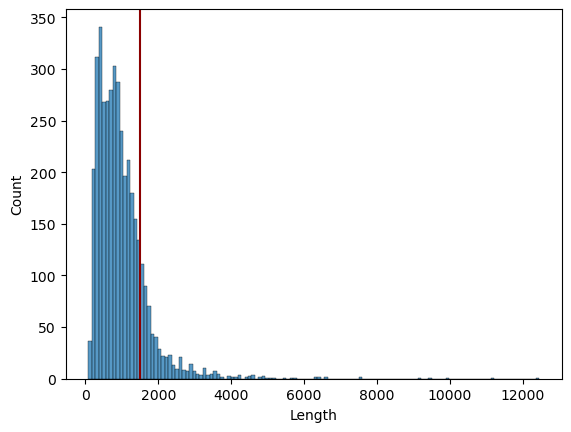

In [89]:
sns.histplot(data=h37Rv_genes,
             x='Length'
            )

plt.axvline(h37Rv_genes.query("Symbol=='sugI'").Length.values[0], color='darkred')

# Get pids with clonal infections (low F2 and same lineage at both timepoints)

In [13]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['Coll2014'].nunique()).query("Coll2014 == 1").index.values
pids_with_same_lineage = set(pids_with_same_lineage).intersection(pd.DataFrame(df_longitudinal_pids.groupby('pid')['Freschi2020'].nunique()).query("Freschi2020 == 1").index.values)
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

print(f"{len(pids_with_same_lineage)}/{df_longitudinal_pids.pid.nunique()} pids have the same lineage assigned to both samples")

include_pids_consistent_mixed_lineages = []

for pid in df_longitudinal_pids.query("pid not in @pids_with_same_lineage and pid not in @pids_with_low_F2").pid.unique():
    lineage_1, lineage_2 = df_longitudinal_pids.query("pid==@pid").Coll2014.unique()
    
    lineage_1 = lineage_1.split(',')
    lineage_2 = lineage_2.split(',')
    
    if len(set(lineage_1).intersection(lineage_2)) > 0:
        include_pids_consistent_mixed_lineages.append(pid)
        
candidate_mixed_pids = df_longitudinal_pids.query("pid not in @pids_with_same_lineage").pid.unique()

check_fastlin_samples = list(set(candidate_mixed_pids) - set(include_pids_consistent_mixed_lineages))

for pid in check_fastlin_samples:
    
    samples = df_longitudinal_pids.query("pid==@pid").SampleID.values
    assert len(samples) == 2
    
    fastlin_1 = pd.read_csv(f"{H37Rv_ref_dir}/{samples[0]}/{samples[0]}/fastlin/output.txt", sep='\t')
    fastlin_2 = pd.read_csv(f"{H37Rv_ref_dir}/{samples[1]}/{samples[1]}/fastlin/output.txt", sep='\t')
    
    sample_1_lineages = fastlin_1['lineages'].values[0].split(',')
    sample_1_lineages = [lineage.split(' (')[0].strip() for lineage in sample_1_lineages]
        
    sample_2_lineages = fastlin_2['lineages'].values[0].split(',')
    sample_2_lineages = [lineage.split(' (')[0].strip() for lineage in sample_2_lineages]
         
    if len(set(sample_1_lineages).intersection(sample_2_lineages)) > 0:
        include_pids_consistent_mixed_lineages.append(pid)
        
print(f"    {len(include_pids_consistent_mixed_lineages)} pids with mixed lineages have consistent mixing")
        
df_longitudinal_pids = df_longitudinal_pids.query("pid in @pids_with_same_lineage | pid in @include_pids_consistent_mixed_lineages").reset_index(drop=True)
print(f"{df_longitudinal_pids.pid.nunique()} pids have the same lineage or consistent mixing")

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")
print(f"    {df_longitudinal_pids.loc[pd.isnull(df_longitudinal_pids['screen_prevpid'])].query('pid in @pids_with_same_lineage_and_low_F2').pid.nunique()} unique participants have F2 ≤ {F2_max} and matching lineages between timepoints")

315 pids
293/315 pids have the same lineage assigned to both samples
    16 pids with mixed lineages have consistent mixing
309 pids have the same lineage or consistent mixing
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    273 unique participants have F2 ≤ 0.03 and matching lineages between timepoints


# Read in the R Mixed Model Predictions

In [17]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{model_dir}/fixed_variants.csv.gz", compression='gzip')

#     # 3037377 was not excluded for this reason, but it's problematic. It's typically a fixed variant, but the coverage drops substantially
#     exclude_pos = [454295, 554179, 630722, 2338275, 2338811, 2338961, 3037377, 3296843, 3851887, 3851888, 4328030]
#     df_fixed_variants = df_fixed_variants.query("POS not in @exclude_pos")
    
    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0 & POS >= @first_pos & POS <= @last_pos & AF <= @AF_thresh").POS.values

        if len(false_lowAF_variant_sites) > 0:
            remove_pos = df_fixed_variants.query("pid==@pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh").POS.unique()
            
#             if len(remove_pos) > 0:
#                 print(pid, len(remove_pos))
            
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh)")
        
    # only apply the linear mixed model filter to low frequency variants
    df_val_variants = df_val_variants.query("(pred_class == 1 & POS >= @first_pos & POS <= @last_pos) | POS < @first_pos | POS > @last_pos")

    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    df_variants = pd.concat([df_train_variants.query("Real == 1"), df_val_variants])
    
    exclude_pos = df_train_variants.query("False_in_all_Ground_Truth_Samples==1").POS.unique()
    print(f"Excluding {len(exclude_pos)} sites that were always false in the ground truth data")

    df_variants = df_variants.query("POS not in @exclude_pos").reset_index(drop=True)
    
    # add in the fixed variants
    if 'Paired_Sample_Num' in df_pids.columns:
        df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Paired_Sample_Num']], on='SampleID')
    else:
        df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

    df_variants.loc[df_variants['Region'].str.contains('NC'), 'Variant_Type'] = 'Intergenic'

    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
                          (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
                          (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
                          (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
    
    # exclude genes Rv2081c and Rv2082. Very problematic for low frequency variant calling. But keep for fixed variants
    df_variants = df_variants.query("~(POS >= 2338065 & POS <= 2340874)")
        
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [19]:
# df_variants, df_lowAF_variants = read_in_process_variants("./unmixed_only", df_longitudinal_pids)
df_variants, df_lowAF_variants = read_in_process_variants("./unmixed_only", df_trust_patients)

len(df_variants), len(df_lowAF_variants)

Excluding 118 sites that were always false in the ground truth data


(729306, 1793)

# Check Classification Accuracy on the Training Data

In [54]:
def compute_classification_metrics(model_dir, exclude_false_sites=False, clonal_only=True):
    
    df = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")
    df_val = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    if clonal_only:
        df = df.query("F2 <= @F2_max")
    
    # a variant with 0.90 < AF ≤ 0.95 that and has Real = 0 is a fixed variant that should have AF > 0.95, but due to freebayes' quirks, it has a lower AF
    # so pred_class should be 0. It will probably get pred_class = 1 because it's a high quality variant, just not unfixed
    # df.loc[(df['AF'] > 0.9) & (df['Real'] == 0), 'pred_class'] = 0

    print(f"{df.Real.sum()} real low-AF variants, {len(df) - df.Real.sum()} false low-AF variants")
    
    precision_vals, recall_vals, _ = sklearn.metrics.precision_recall_curve(df['Real'], df['predicted'])

    fpr, tpr, _ = sklearn.metrics.roc_curve(df['Real'], df['predicted'])

    auc = sklearn.metrics.roc_auc_score(df['Real'], df['predicted'])
    
    # for samples that have False_in_all_Ground_Truth_Samples = 1, set pred_class as 0
    if exclude_false_sites:
        df.loc[df['False_in_all_Ground_Truth_Samples']==1, 'pred_class'] = 0

    TP = len(df.query("Real == 1 & pred_class == 1"))
    TN = len(df.query("Real == 0 & pred_class == 0"))
    FN = len(df.query("Real == 1 & pred_class == 0"))
    FP = len(df.query("Real == 0 & pred_class == 1"))

    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    specificity = TN / (TN + FP)
    F1 = 2 * (precision * recall) / (precision + recall)
    
    print(f"    TP: {TP}")
    print(f"    TN: {TN}")
    print(f"    FN: {FN}")
    print(f"    FP: {FP}")
    
    return pd.DataFrame({'AUC': auc, 'F1': F1, 'PPV': precision, 'Recall': recall, 'Specificity': specificity}, index=[0]), df, df_val

In [55]:
model_dir = "unmixed_only"
# df_classification_metrics, _ = compute_classification_metrics(model_dir)
df_classification_metrics_exclude_bad_sites, df_train, df_val = compute_classification_metrics(model_dir, exclude_false_sites=True)

394 real low-AF variants, 552 false low-AF variants
    TP: 381
    TN: 550
    FN: 13
    FP: 2


In [40]:
df_classification_metrics_exclude_bad_sites

,AUC,F1,PPV,Recall,Specificity
0,0.996427,0.980695,0.994778,0.967005,0.996377


In [42]:
df_val.pred_class.value_counts()

pred_class
1    2061
0    1324
Name: count, dtype: int64

In [43]:
df_val.pred_class.sum() / len(df_val)

0.6088626292466766

In [56]:
df_val.query("SampleID=='MFS-578' & pred_class==1").predicted.min()

0.992979274353538

In [32]:
df_train.query("pred_class==1 & Real==0")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF']]

,pid,SampleID,POS,REF,ALT,AF
185,T0247,MFS-160,3717219,C,G,0.139073
520,T0330,MFS-395,3062615,G,A,0.943878


In [15]:
missed_pos = df_train.query("pred_class==0 & Real==1").sort_values('predicted').POS.unique()
len(missed_pos)

12

In [26]:
df_train.query("False_in_all_Ground_Truth_Samples==1").POS.nunique()

115

In [27]:
df_train.query("False_in_all_Ground_Truth_Samples==1").GENE.value_counts()

GENE
Rv3433c           124
Rv2319c            99
uspC               71
Rv2082             56
cyp138             30
                 ... 
fadD31              1
pknH                1
mmpL6               1
Rv3196A-Rv3197      1
Rv1700              1
Name: count, Length: 90, dtype: int64

In [23]:
df_train.query("POS==4338594")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'predicted', 'pred_class', 'Real', 'Mean_BQ_ALT_allele', 'COV', 'COV_MAX_ROLLING_AVG',
       'CLIPPED_BASES', 'DISCORDANT_READS', 'COV_RATIO',
       'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO']]

,pid,SampleID,POS,REF,ALT,predicted,pred_class,Real,Mean_BQ_ALT_allele,COV,COV_MAX_ROLLING_AVG,CLIPPED_BASES,DISCORDANT_READS,COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO
455,T0284,MFS-325,4338594,A,T,0.140231,0,1,32.802372,376,454.65,35,5,0.827010,0.013298,0.093085
463,T0284,MFS-326,4338594,A,T,0.128843,0,1,33.118483,295,348.82,29,2,0.845708,0.006780,0.098305


In [21]:
df_val.query("POS in @missed_pos")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'predicted', 'pred_class', 'Mean_BQ_ALT_allele', 'COV', 'COV_MAX_ROLLING_AVG',
       'CLIPPED_BASES', 'DISCORDANT_READS', 'COV_RATIO',
       'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO']]

,pid,SampleID,POS,REF,ALT,predicted,pred_class,Mean_BQ_ALT_allele,COV,COV_MAX_ROLLING_AVG,CLIPPED_BASES,DISCORDANT_READS,COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO
539,T0280,MFS-300,4338594,A,C,0.000977,0,33.012448,294,343.40,22,3,0.856144,0.010204,0.074830
572,T0288,MFS-306,4338594,A,T,0.000027,0,32.654545,321,382.73,28,6,0.838711,0.018692,0.087227
3356,T0476,MFS-894,3606001,T,G,0.997623,1,39.433071,259,291.87,4,5,0.887381,0.019305,0.015444


In [10]:
df_classification_metrics_exclude_bad_sites

,AUC,F1,PPV,Recall,Specificity
0,0.996427,0.980695,0.994778,0.967005,0.996377


In [23]:
df_val.pred_class.value_counts()

pred_class
1    2070
0    1326
Name: count, dtype: int64

In [80]:
FN_pos = df_train.query("Real == 1 & pred_class == 0").POS.unique()

df_train.query("Real == 1 & pred_class == 0")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'GENE', 'AF', 'predicted', 'pred_class', 'False_in_all_Ground_Truth_Samples', 'Real', 'COV', 'COV_MAX_ROLLING_AVG', 'COV_RATIO',
       'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO', 'Mean_BQ_ALT_allele']].sort_values('COV_RATIO').query("SampleID=='MFS-135'")

,pid,SampleID,POS,REF,ALT,GENE,AF,predicted,pred_class,False_in_all_Ground_Truth_Samples,Real,COV,COV_MAX_ROLLING_AVG,COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO,Mean_BQ_ALT_allele
119,T0225,MFS-135,3501681,C,T,PPE50,0.343891,0.078612,0,0,1,250,404.32,0.618322,0.0520,0.004000,31.284211
120,T0225,MFS-135,3606001,T,G,desA3,0.563830,0.062420,0,0,1,399,433.81,0.919757,0.0401,0.027569,33.092437
121,T0225,MFS-135,3606002,G,A,desA3,0.563830,0.073868,0,0,1,401,434.38,0.923155,0.0399,0.027431,33.480176


In [79]:
# do I set 4338594 as real?
# 3606001 is real, but it's actually a fixed variant and should have AF > 0.95. It has a low AF because freebayes does that thing
# where if two variants of different AFs are close to each other, it averages (or something like that) their AFs, so the low variant has higher AF than it should
# and the high variant has a lower AF than it should
df_val.query("POS in @FN_pos")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'Coll2014', 'F2', 'predicted', 'pred_class']]

,pid,SampleID,POS,REF,ALT,AF,GENE,Coll2014,F2,predicted,pred_class
540,T0280,MFS-300,4338594,A,C,0.858779,whiB6-Rv3863,4.3.4.2.1,0.006909,0.000977,0
573,T0288,MFS-306,4338594,A,T,0.570896,whiB6-Rv3863,2.2.1.1,0.012589,0.000027,0
3367,T0476,MFS-894,3606001,T,G,0.866935,desA3,3,0.008622,0.997623,1


In [32]:
def evaluate_thresholds(model_dir, true_col='Real', pred_col='pred_class', exclude_false_sites=True):
    """
    Evaluate classifier performance at thresholds from 0 to 0.9.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the true and predicted columns.
    true_col : str
        Name of the column with true binary labels (0 or 1).
    pred_col : str
        Name of the column with predicted probabilities (floats 0–1).

    Returns
    -------
    pandas.DataFrame
        DataFrame with threshold, sensitivity (recall), precision, F1, and (precision + recall).
    """
    
    df = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")
    
    thresholds = np.arange(0.0, 1.0, 0.1)
    results = []

    # for samples that have False_in_all_Ground_Truth_Samples = 1, set pred_class as 0
    # don't want to include these when determining the threshold because we already know they are wrong
    if exclude_false_sites:
        df.loc[df['False_in_all_Ground_Truth_Samples']==1, 'pred_class'] = 0
        df_compute_thresh = df.query("False_in_all_Ground_Truth_Samples==0")
    else:
        df_compute_thresh = df.copy()
        
    for t in thresholds:
        df_compute_thresh['y_pred'] = (df_compute_thresh[pred_col] >= t).astype(int)

        TP = len(df_compute_thresh.query("Real == 1 & y_pred == 1"))
        TN = len(df_compute_thresh.query("Real == 0 & y_pred == 0"))
        FN = len(df_compute_thresh.query("Real == 1 & y_pred == 0"))
        FP = len(df_compute_thresh.query("Real == 0 & y_pred == 1"))

        precision = TP / (TP + FP)
        recall = TP / (TP + FN)
        specificity = TN / (TN + FP)
        F1 = 2 * (precision * recall) / (precision + recall)

        results.append({
            "threshold": round(t, 2),
            "sensitivity": recall,
            "precision": precision,
            "F1": F1,
            "sensitivity+precision": recall + precision
        })

    return pd.DataFrame(results)


In [37]:
model_dir = "unmixed_only"
classification_metrics = evaluate_thresholds(model_dir, true_col='Real', pred_col='pred_class', exclude_false_sites=False)

In [38]:
classification_metrics

,threshold,sensitivity,precision,F1,sensitivity+precision
0,0.0,1.000000,0.413866,0.585438,1.413866
1,0.1,0.967005,0.967005,0.967005,1.934010
2,0.2,0.967005,0.967005,0.967005,1.934010
3,0.3,0.967005,0.967005,0.967005,1.934010
4,0.4,0.967005,0.967005,0.967005,1.934010
5,0.5,0.967005,0.967005,0.967005,1.934010
6,0.6,0.967005,0.967005,0.967005,1.934010
7,0.7,0.967005,0.967005,0.967005,1.934010
8,0.8,0.967005,0.967005,0.967005,1.934010
9,0.9,0.967005,0.967005,0.967005,1.934010


# Read in All Indels (Fixed and Unfixed)

In [4]:
df_indels = pd.read_csv("indels_called_from_H37Rv.csv")
print(df_indels.SampleID.nunique())

AF_min = 0.05
AF_max = 0.9

# these are some cases where there are reads with too many mismatches (like lots of SNPs in close proximity), and they will increase the Total_Reads field
# not sure how to get rid of them, so I think just use the original AF column. 
# don't do this if my adjustment is down to absent. Those are really absent.
# only change the ones that have a large change between AF and AF_Adj
df_indels.loc[(df_indels['AF'] - df_indels['AF_Adj'] > 0.05) & (df_indels['AF'] >= AF_min) & (df_indels['AF_Adj'] >= AF_min), 'AF_Adj'] = df_indels.loc[(df_indels['AF'] - df_indels['AF_Adj'] > 0.05) & (df_indels['AF'] > AF_max) & (df_indels['AF_Adj'] >= AF_min)]['AF']

df_indels = df_indels.merge(df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2")[['pid', 'SampleID', 'Original_ID', 'Sampling_Week', 'Coll2014', 'Freschi2020', 'F2', 'Lineage', 'Paired_Sample_Num']], on=['SampleID', 'pid'])
print(f"{df_indels.SampleID.nunique()} WGS samples across {df_indels.pid.nunique()} pids")

df_indels = df_indels.drop_duplicates().reset_index(drop=True)

df_indels['Indel'] = df_indels['POS'].astype(str) + '_' + df_indels['REF'] + '_' + df_indels['ALT']
df_indels['Region'] = df_indels['POS'].map(h37Rv_coords_dict)

df_unfixed_indels = df_indels.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max")
df_fixed_indels = df_indels.query("AF_Adj > @AF_max")

774
542 WGS samples across 271 pids


# Get matrices to compare differences

In [399]:
sample_1_indels, sample_2_indels, indel_differences = convert_variants_to_matrices(df_indels, 'Indel')

(271, 1051)


In [400]:
change_thresh = 0.1
df_large_indel_changes = pd.DataFrame(columns = ['Indel', 'pidsChange', 'PosChange', 'NegChange'])
i = 0

for variant in indel_differences.columns:
    
    df_change = indel_differences.loc[(indel_differences[variant] > change_thresh) | (indel_differences[variant] < -change_thresh)]
    
    if len(df_change) > 0:
        pos_change = df_change.loc[df_change[variant] > 0][variant].mean()
        neg_change = df_change.loc[df_change[variant] < 0][variant].mean()

        df_large_indel_changes.loc[i, :] = [variant, len(df_change), pos_change, neg_change]
        i += 1

In [401]:
df_large_indel_changes.sort_values('pidsChange', ascending=False)

,Indel,pidsChange,PosChange,NegChange
19,968426_A_AGCCGGGTTG,24,0.113241,-0.287222
10,3131469_T_TTGTCGGCGA,17,0.530058,-0.305693
0,1042692_T_TCTTGTTCACCCAGTACCTGTCCAA,16,0.428772,-0.223489
27,428186_CTGCCGGTGTTGGTGCTGCCGGTGTTGTAGCTGCCCGTG...,15,0.9,-1.0
12,3331361_ACG_A,11,0.993313,-0.999482
...,...,...,...,...
125,4383146_C_CGGGCA,1,NaN,-0.989071
126,868158_G_GC,1,0.994737,NaN
127,1760164_T_TGGGG,1,0.12,NaN
128,3296379_C_CCGCGGCG,1,NaN,-0.981481


In [407]:
df_indels.query("Indel=='968426_A_AGCCGGGTTG'").AF.min(), df_indels.query("Indel=='968426_A_AGCCGGGTTG'").AF.max()

(0.6166666666666667, 0.8874172185430463)

In [414]:
variant = '968426_A_AGCCGGGTTG'

indel_differences.loc[(indel_differences[variant] > change_thresh) | (indel_differences[variant] < -change_thresh)][variant]

T0002    0.102330
T0008    0.106352
T0031    0.100318
T0121    0.116830
T0136    0.117465
T0143    0.101343
T0162   -0.119573
T0166   -0.122549
T0170    0.106074
T0174   -0.112097
T0179   -0.108057
T0230   -0.123308
T0231    0.146958
T0269   -0.178850
T0274   -0.707317
T0295   -0.188211
T0328    0.110903
T0331   -0.101231
T0335   -0.133105
T0359    0.121429
T0365    0.115651
T0368   -0.205200
T0396   -0.825137
T0447   -0.809249
Name: 968426_A_AGCCGGGTTG, dtype: float64

In [415]:
search_pid = 'T0004'
df_longitudinal_pids.query("pid==@search_pid")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
4,T0004,04-01,MFS-1,1,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.008274,2,1,2
5,T0004,04-08,MFS-2,8,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.007192,2,2,2


In [416]:
df_indels.query("Indel==@variant & pid==@search_pid")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,pid,Original_ID,Sampling_Week,Coll2014,Freschi2020,F2,Lineage,Paired_Sample_Num,Indel,Region
21,968426,A,AGCCGGGTTG,0.713287,102,143,156.0,156.0,1.0,MFS-1,T0004,04-01,1,2.2.1.1,2.2.1.1.1,0.008274,2,1,968426_A_AGCCGGGTTG,PE_PGRS15
6150,968426,A,AGCCGGGTTG,0.789157,131,166,167.0,167.0,1.0,MFS-2,T0004,04-08,8,2.2.1.1,2.2.1.1.1,0.007192,2,2,968426_A_AGCCGGGTTG,PE_PGRS15


In [423]:
969703-967883

1820

In [424]:
970244-968424

1820

In [420]:
h37Rv_genes.query("Symbol=='PE_PGRS15'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
897,897,CDS,968424,970244,-,0.0,Rv0872c,PE_PGRS15,Function unknown,PE-PGRS family protein PE_PGRS15,...,Q79FV3,NaN,NaN,NaN,Mb0896c,NaN,NaN,NaN,NaN,NaN


In [366]:
sample = 'MFS-1'
in_vcf = f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.split.vcf"
vcf_in = pysam.VariantFile(in_vcf)

for record in vcf_in:

    pos = record.pos
    ref = record.ref
    alt = record.alts
    depth = record.info['DP']
    ao = record.info['AO']
    mqm = record.info['MQM']
    meanAlt = record.info['MEANALT']
    saf = record.info['SAF']
    sar = record.info['SAR']
    
    if pos == 1753523:

        # vcfwave splits multiallelics, so there should only be one ALT
        assert len(alt) == 1
        alt = alt[0]

        cigar_strings = list(record.info['CIGAR'])

        matched_cigar_strings = []

        keep_idx = None

        if len(cigar_strings) > 1 and len(ao) > 1:

            found_match_global = False

            for cigar_string in cigar_strings:
                found_match, matched_cigar = match_variant_to_cigar(ref, alt, cigar_string, collapse=True)

                if found_match:
                    matched_cigar_strings.append(matched_cigar)
                    found_match_global = True

            # if no match was found after going through the collapsed versions, then check the uncollapsed cigar tuples.
            if not found_match_global:
                # the collapsed one is more accurate because of the problems of reporting multiple variants at different AFs on the same haplotype.
                # see 163705 and 163710 in MFS-172 for an example. 163705 is at high frequency, 163710 is at unfixed frequency
                for cigar_string in cigar_strings:
                    found_match, matched_cigar = match_variant_to_cigar(ref, alt, cigar_string, collapse=False)

                    if found_match:
                        matched_cigar_strings.append(matched_cigar)

            if len(matched_cigar_strings) > 0:
                keep_idx = [list(cigar_strings).index(matched_cigar) for matched_cigar in np.unique(matched_cigar_strings)]
                
        else:
            print(ao, depth, cigar_strings)
                # print(pos, ref, alt, ao[keep_idx], depth)
            # else:
            # ignore. Usually low quality variants. Very rarely haplotype variants of different AFs that can not be resolved without writing a whole new variant caller :(
            # raise ValueError(pos, ref, alt, cigar_strings, f"not found in {in_vcf}") 

        # # get individual AO. If the index is longer than AO, then that variant is probably not real. So set AO = 0
        # # need to also split MQM because we use that for filtering. For completeness, also split mean alt
        # if keep_idx is not None:
        #     new.info['AO'] = int(np.sum(np.array(ao)[keep_idx]))
        #     new.info['MQM'] = np.sum(np.array(mqm)[keep_idx])
        #     new.info['MEANALT'] = np.sum(np.array(meanAlt)[keep_idx])
        #     new.info['SAF'] = int(np.sum(np.array(saf)[keep_idx]))
        #     new.info['SAR'] = int(np.sum(np.array(sar)[keep_idx]))
        # else:
        #     new.info['AO'] = 0
        #     new.info['MQM'] = 0
        #     new.info['MEANALT'] = 0
        #     new.info['SAF'] = 0
        #     new.info['SAR'] = 0

(226,) 237 ['1M1I6M']


In [372]:
del_fNames = glob.glob(f"{H37Rv_ref_dir}/*/freebayes/*fixedAO*")
len(del_fNames)

1722

In [373]:
for fName in del_fNames:
    os.remove(fName)

In [367]:
226/237

0.9535864978902954

In [361]:
cigar_strings

['1M1I6M']

In [362]:
cigar_string

'1X2M'

In [358]:
matched_cigar_strings

[]

In [360]:
ref, alt

('C', ('T',))

In [359]:
match_variant_to_cigar(ref, alt, cigar_string, collapse=False)

(True, '1X2M')

In [ ]:
def collapse_cigar_tuples(cigar_tuples):
    """
    Combine consecutive cigar operations with the same operator.
    Example:
        [('2', 'X'), ('3', 'M'), ('1', 'X')] → [('3', 'X'), ('3', 'M')]
    """
    
    df_cigar_tuples = pd.DataFrame(cigar_tuples, columns=['NumBases', 'Operator'])
    df_cigar_tuples['NumBases'] = df_cigar_tuples['NumBases'].astype(int)

    df_cigar_tuples_collapsed = pd.DataFrame(df_cigar_tuples.groupby('Operator')['NumBases'].sum()).reset_index()
    
    return [(row['NumBases'], row['Operator']) for i, row in df_cigar_tuples_collapsed.iterrows()]


def match_variant_to_cigar(ref, alt, cigar_string, collapse=True):
    
    # X = substitution, D = deletion, I = insertion
    if len(ref) == len(alt):
        aln_symbol = 'X'
    elif len(ref) > len(alt):
        aln_symbol = 'D'
    else:
        aln_symbol = 'I'
        
    if aln_symbol == 'X':
        variant_length = len(ref)
    else:
        variant_length = abs(len(ref) - len(alt))
        
    # convert CIGAR string to tuples
    cigar_tuples = re.findall(r"(\d+)([MIDNSHP=X])", cigar_string)
    
    # add numbers from the same operator, so 2X3M1X would be [('3', 'X'), ('3', 'M')]
    if collapse:
        cigar_tuples = collapse_cigar_tuples(cigar_tuples)
            
    match = False
    
    for num_bases, operator in cigar_tuples:
        if operator == aln_symbol and int(num_bases) == variant_length:
            return True, cigar_string
    
    return match, None

In [338]:
matched_cigar_strings

['1M1D1M']

In [339]:
cigar_strings

['1M1D1M', '1X2M']

T0005   -1.000000
T0020    1.000000
T0026    1.000000
T0040    1.000000
T0048    1.000000
           ...   
T0470   -1.000000
T0471    1.000000
T0472   -0.006024
T0474    1.000000
T0475   -1.000000
Name: 4095001_CG_C, Length: 69, dtype: float64

In [90]:
def convert_variants_to_matrices(df_variants, variant_col, baseline_only=False):
    
    variant_matrix = []

    # fixed_AF_thresh = 1.2

    # use df_lowAF_variants because the signal for low frequency variants gets drowned out by tons of fixed SNPs
    for pid in df_variants.pid.unique():

        single_pid_matrix = df_variants.query("pid==@pid").pivot(index='Paired_Sample_Num', columns=variant_col, values='AF')
        
        single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)

        # variant_matrix.append(single_pid_matrix[keep_variants])
        variant_matrix.append(single_pid_matrix)

    variant_matrix = pd.concat(variant_matrix).fillna(0)

    sample_1_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_1')]
    
    # remove the suffixes from the indexes
    sample_1_variants.index = sample_1_variants.index.str.split('_').str[0]
    
    if not baseline_only:
        sample_2_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_2')]
        sample_2_variants.index = sample_2_variants.index.str.split('_').str[0]    

        # make sure they have the same samples
        all_pids = np.sort(list(set(sample_1_variants.index).union(sample_2_variants.index)))

        missing_pids_sample1 = list(set(all_pids) - set(sample_1_variants.index))
        missing_pids_sample2 = list(set(all_pids) - set(sample_2_variants.index))

        sample_1_variants = pd.concat([sample_1_variants,
                                   pd.DataFrame(index=missing_pids_sample1, columns=sample_1_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        sample_2_variants = pd.concat([sample_2_variants,
                                   pd.DataFrame(index=missing_pids_sample2, columns=sample_2_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        indel_differences = sample_2_variants - sample_1_variants
        print(indel_differences.shape)

        return sample_1_variants, sample_2_variants, indel_differences
    
    else:
        print(sample_1_variants.shape)
        return sample_1_variants

In [61]:
df_indels.query("AF - AF_Adj > 0.05").sort_values('AF_Adj').sort_values('POS')

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,pid
24721,33207,G,GC,0.056522,13,230,0.0,222.0,0.0,MFS-447,T0362
59823,33207,G,GC,0.055147,15,272,0.0,251.0,0.0,MFS-890,T0428
9649,2245826,G,GA,1.000000,5,5,0.0,0.0,0.0,MFS-27,T0047
8598,3480375,GA,G,0.063380,9,142,0.0,0.0,0.0,MFS-23,T0042
43615,3480375,GA,G,0.059880,10,167,0.0,0.0,0.0,MFS-69,T0140


In [74]:
df_indels

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,pid
0,28366,AT,A,0.983740,242,246,234.0,235.0,0.995745,MFS-1,T0004
1,33207,G,GGC,0.905455,249,275,238.0,239.0,0.995816,MFS-1,T0004
2,49690,GCC,G,0.992565,267,269,282.0,283.0,0.996466,MFS-1,T0004
3,68337,T,TC,1.000000,320,320,301.0,301.0,1.000000,MFS-1,T0004
4,99162,TCGGTGTGCG,T,1.000000,159,159,245.0,245.0,1.000000,MFS-1,T0004
...,...,...,...,...,...,...,...,...,...,...,...
60955,4338595,GC,G,1.000000,209,209,262.0,262.0,1.000000,MFS-99,T0181
60956,4357258,C,CT,1.000000,202,202,198.0,198.0,1.000000,MFS-99,T0181
60957,4369672,GC,G,1.000000,132,132,129.0,129.0,1.000000,MFS-99,T0181
60958,4383144,C,CCGGGG,0.988235,168,170,208.0,208.0,1.000000,MFS-99,T0181


271

In [257]:
samples_from_pids_with_same_lineage = df_longitudinal_pids.query("pid in @pids_with_same_lineage").SampleID.values
len(samples_from_pids_with_same_lineage)

556

In [266]:
df_longitudinal_pids.query("pid=='T0066'")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
94,T0066,66-01,MFS-39,1,2.2.1.1,2.2.1.1.1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN,0.109723,2,1,2
95,T0066,66-08,MFS-40,8,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.007655,2,2,2


In [265]:
df_longitudinal_pids.query("pid in @pids_with_same_lineage").query("F2 > 0.03")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
94,T0066,66-01,MFS-39,1,2.2.1.1,2.2.1.1.1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN,0.109723,2,1,2
150,T0116,S0116-01,MFS-577,1,2.2.1.1,2.2.1.1.1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN,0.052222,2,1,2
256,T0198,S0198-02,MFS-377,2,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.109970,2,1,2
448,T0364,S0364-01,MFS-450,1,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,0.088172,2,1,2
484,T0393,S0393-01,MFS-485,1,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.081212,2,1,2
485,T0393,S0393-06,MFS-486,6,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.035206,2,2,2
528,T0441,S0441-01,MFS-705,1,2.2.1.1,2.2.1.1.1,"beijing,haarlem,mungi","lin2.2.1,pacific_RD150",NaN,0.154853,2,1,2
529,T0441,S0441-08,MFS-822,8,2.2.1.1,2.2.1.1.1,"beijing,haarlem,mungi","lin2.2.1,pacific_RD150",NaN,0.035792,2,2,2
548,T0457,S0457-01,MFS-835,1,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.047727,2,1,2


In [154]:
def apply_freebayes_lowAF_QCfilters(df_variants, DP=True, AF_min=0.05, AF_max=0.98, MQ_thresh=40, num_support_each_direction=2):
    '''
    Use 0.98 when doing the validaiton using the personal ref genomes because if there's a variant present at 100% relative to H37Rv, there won't be a variant when called against the
    personal reference genome because it's purely the nucleotide in the assembly. 
    
    But for calling variants against H37Rv, later on, keep everything
    '''
    
    # add AF column
    df_variants['AF'] = df_variants['AO'] / df_variants['DP']
    
    if DP:
        df_lowAF_variants = df_variants.query("DP >= 5 & AF >= @AF_min & AF <= @AF_max & MQM >= @MQ_thresh")
    else:
        df_lowAF_variants = df_variants.query("AF >= @AF_min & AF <= @AF_max & MQM >= @MQ_thresh")

    df_lowAF_variants = pd.concat([df_lowAF_variants.query("(REF.str.len() - ALT.str.len() > 10)"),
                                   df_lowAF_variants.query("~(REF.str.len() - ALT.str.len() > 10) & SAF >= @num_support_each_direction & SAR >= @num_support_each_direction")
                                  ])    
    
    return df_lowAF_variants.reset_index(drop=True)


def keep_middle_percentage_of_reads(df, n_prop):
    
    # should be a proportion, not a percentage
    if n_prop > 1:
        n_prop /= 1

    # Calculate how many rows to keep
    n_rows = len(df)
    keep = int(n_rows * n_prop)

    # Calculate start and end indices
    start = (n_rows - keep) // 2
    end = start + keep

    # Slice the middle N%
    return df.iloc[start:end].reset_index(drop=True)

In [155]:
def compute_adjusted_AF_indels(df_indels, chrom, bam_file, n_prop=0.50, dist_from_indel=10):
    
    df_indels = df_indels.reset_index(drop=True)
    
    bam = pysam.AlignmentFile(bam_file, "rb")

    for i, row in df_indels.iterrows():
        
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']
        
        indel_length = abs(len(ref) - len(alt))
        
        if len(alt) > len(ref):
            search_string = 'I'
            search_val = 1
        else:
            search_string = 'D'
            search_val = 2
            
        reads_overlapping = []
        
        for read in bam.fetch(chrom, pos - 1, pos):  # pysam uses 0-based, half-open

            # exclude reads with supplementary alignments, secondary alignments, or are discordantly paired
            if not read.is_supplementary and not read.is_secondary and read.is_proper_pair:
            
                if read.cigarstring is not None:

                    indel_cigar_length = sum(length for (op, length) in (read.cigartuples or []) if op == search_val and length == indel_length)

                    # get number of bases soft clipped from this read
                    num_soft_clipped_bases = sum(length for (op, length) in (read.cigartuples or []) if op == 4)

                    reads_overlapping.append({
                        "read_name": read.query_name,
                        "ref_start": read.reference_start + 1,  # make it 1-based
                        "ref_end": read.reference_end,
                        "num_indel": indel_cigar_length,
                        "num_soft_clipped": num_soft_clipped_bases,
                        "cigar": read.cigarstring,
                        "cigartuples": read.cigartuples,
                    })

        df_overlapping_reads = pd.DataFrame(reads_overlapping).sort_values(['ref_start', 'ref_end'])
        
        if len(df_overlapping_reads) > 0:
            
            # take the middle N% of reads? No, this is hard to tune because it needs to be low enough to work for some fixed indels, 
            # but high enough for very rare indels (like AF < 10%) so that we still detect them
            # df_reads_close_to_indel = keep_middle_percentage_of_reads(df_overlapping_reads, n_prop)
    
            # include a read only if neither its start nor end are within 10 base pairs of the indel site
            df_reads_close_to_indel = df_overlapping_reads.loc[(abs(df_overlapping_reads['ref_start'] - pos) >= dist_from_indel) & 
                                                               (abs(df_overlapping_reads['ref_end'] - pos) >= dist_from_indel)
                                                              ]

            # also exclude reads that start or end in the middle of the indel            
            # this position is inclusive. So the read must not have a start or end within this
            indel_end = pos + indel_length

            df_reads_close_to_indel = df_reads_close_to_indel.loc[~((df_reads_close_to_indel['ref_start'] >= pos) & (df_reads_close_to_indel['ref_start'] <= indel_end))]

            df_reads_close_to_indel = df_reads_close_to_indel.loc[~((df_reads_close_to_indel['ref_end'] >= pos) & (df_reads_close_to_indel['ref_end'] <= indel_end))]

            # AND include a read only if neither its start nor end are within 10 base pairs of the deletion END
            df_reads_close_to_indel = df_reads_close_to_indel.loc[(abs(df_reads_close_to_indel['ref_start'] - indel_end) >= dist_from_indel) & 
                                                                  (abs(df_reads_close_to_indel['ref_end'] - indel_end) >= dist_from_indel)
                                                                 ]


            # AND exclude reads with ANY soft clipping from contributing to the depth
            df_reads_close_to_indel = df_reads_close_to_indel.query("num_soft_clipped == 0")
            
            # add a check to see if the start and end of reads that support and don't support the indel are significantly different. If they are, then it's probably a fixed indel.
            # KS test is very sensitive, using the median (Mann-Whitney U test) is more robust to outliers
            df_reads_close_to_indel['Indel'] = (df_reads_close_to_indel['num_indel'] > 0).astype(int)
            
            if df_reads_close_to_indel.Indel.nunique() == 2:

                start_pval = st.mannwhitneyu(df_reads_close_to_indel.query("Indel==1").ref_start,
                                            df_reads_close_to_indel.query("Indel==0").ref_start
                                           ).pvalue

                end_pval = st.mannwhitneyu(df_reads_close_to_indel.query("Indel==1").ref_end,
                                            df_reads_close_to_indel.query("Indel==0").ref_end
                                           ).pvalue

                # set the AF as 1
                if start_pval < 0.01 and end_pval < 0.01:
                    # subtract the soft-clipped reads from the total reads. These will not support the indel, which doesn't mean that the indel is present at low frequency. It's artifactual
                    df_indels.loc[i, ['Indel_Support', 'Total_Reads', 'AF_Adj']] = [len(df_reads_close_to_indel), 
                                                                                    len(df_reads_close_to_indel),# - row['CLIPPED_BASES'],
                                                                                    1
                                                                                   ]
                    
                else:
                    num_reads_close_supporting_indel = len(df_reads_close_to_indel.query("num_indel > 0"))

                    # these are very low quality indels. If all reads have been excluded, then it was probably an area of tons of discordant alignments, meaning there's no low frequency indel. 
                    # It's reference bias due to SVs
                    if len(df_reads_close_to_indel) == 0:
                        adj_AF = 0
                        print(sample, pos)
                    else:
                        adj_AF = num_reads_close_supporting_indel / (len(df_reads_close_to_indel))# - row['CLIPPED_BASES'])

                    # subtract the soft-clipped reads from the total reads. These will not support the indel, which doesn't mean that the indel is present at low frequency. It's artifactual
                    df_indels.loc[i, ['Indel_Support', 'Total_Reads', 'AF_Adj']] = [num_reads_close_supporting_indel, 
                                                                                    len(df_reads_close_to_indel),# - row['CLIPPED_BASES'],
                                                                                    adj_AF
                                                                                   ]

            else:
                num_reads_close_supporting_indel = len(df_reads_close_to_indel.query("num_indel > 0"))

                # these are very low quality indels. If all reads have been excluded, then it was probably an area of tons of discordant alignments, meaning there's no low frequency indel. 
                # It's reference bias due to SVs
                if len(df_reads_close_to_indel) == 0:
                    adj_AF = 0
                    print(sample, pos)
                else:
                    adj_AF = num_reads_close_supporting_indel / (len(df_reads_close_to_indel))# - row['CLIPPED_BASES'])

                # subtract the soft-clipped reads from the total reads. These will not support the indel, which doesn't mean that the indel is present at low frequency. It's artifactual
                df_indels.loc[i, ['Indel_Support', 'Total_Reads', 'AF_Adj']] = [num_reads_close_supporting_indel, 
                                                                                len(df_reads_close_to_indel),# - row['CLIPPED_BASES'],
                                                                                adj_AF
                                                                               ]
            
        else:
            df_indels = pd.DataFrame()

    bam.close()

    return df_indels

In [156]:
samples_lst = os.listdir(personal_ref_dir)
len(samples_lst)

108

In [157]:
# df_run = pd.DataFrame({'A': samples_lst, 'B': samples_lst, 'FQ': 0})

# df_run.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/TRUST_samples_to_run.tsv", index=False, sep='\t', header=None)

In [158]:
# df_variants.query("AO.str.contains(',')")

In [197]:
AF_min = 0.05
AF_max = 0.95

df_indels = pd.read_csv("indels_called_from_H37Rv_v2.csv")

dist_from_indel = 10

df_benchmarking = []

for sample in samples_lst:
    
    ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv").query("AF >= @AF_min & AF <= @AF_max")
    ground_truth_indels = ground_truth.query("REF.str.len() != ALT.str.len()").reset_index(drop=True)
    
    df_candidate_unfixed_indels_adjusted_AF = df_indels.query("SampleID==@sample")

#     # df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")
#     df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.split.fixedAO.final.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")
        
#     df_indels = df_variants.query("REF.str.len() != ALT.str.len()")
    
#     # keep only low frequency variants. Extract fixed variants separately
#     df_indels = apply_freebayes_lowAF_QCfilters(df_indels, AF_min=AF_min, AF_max=AF_max)
    
    df_confusion_matrix = ground_truth_indels[['POS', 'REF', 'ALT', 'AO', 'DP', 'AF']]
    df_confusion_matrix['H37Rv_POS'] = np.nan
    
#     if len(df_indels) > 0:
    
#         # df_soft_clips = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.softClips.tsv.gz", sep='\t', header=None, names=['CHROM', 'POS', 'CLIPPED_BASES'])

#         df_candidate_unfixed_indels = df_indels[['POS', 'REF', 'ALT', 'AF', 'AO', 'DP']].sort_values('POS')#.merge(df_soft_clips, on='POS')
        
# #         # require that the depth be at least the global median, so that we don't get low AF indels called in places with huge reference bias
# #         df_depth = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz", sep='\t', compression='gzip', names=['CHROM', 'POS', 'COV'])
        
# #         min_depth = df_depth.COV.median() / 2
        
# #         low_depth_sites = df_depth.query("COV < @min_depth").POS.values
        
# #         df_candidate_unfixed_indels = df_candidate_unfixed_indels.query("POS not in @low_depth_sites")
        
    if len(df_candidate_unfixed_indels) > 0:

#         df_candidate_unfixed_indels_adjusted_AF = compute_adjusted_AF_indels(df_candidate_unfixed_indels, 
#                                                                              'Chromosome', 
#                                                                              f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam", 
#                                                                              dist_from_indel=dist_from_indel,
#                                                                             )

        del df_confusion_matrix['H37Rv_POS']

        df_confusion_matrix = df_confusion_matrix.merge(df_candidate_unfixed_indels_adjusted_AF.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max")[['POS', 'REF', 'ALT', 'AF', 'AF_Adj']].rename(columns={'POS': 'H37Rv_POS'}), left_on=['POS'], right_on='H37Rv_POS', how='outer')

    df_confusion_matrix['SampleID'] = sample
    df_benchmarking.append(df_confusion_matrix)
    
df_benchmarking = pd.concat(df_benchmarking)

df_benchmarking = df_benchmarking.merge(df_trust_patients[['SampleID', 'pid']], how='left')
assert sum(pd.isnull(df_benchmarking['pid'])) == 0

In [213]:
sample = 'MFS-3'
bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"
AF_min = 0.05
AF_max = 1.2
dist_from_indel = 10

# df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")
df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.split.fixedAO.final.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")

df_indels_single = df_variants.query("REF.str.len() != ALT.str.len()")

# keep only low frequency variants. Extract fixed variants separately
df_indels_single = apply_freebayes_lowAF_QCfilters(df_indels_single, AF_min=AF_min, AF_max=AF_max)
    
df_indels_single = df_indels_single.reset_index(drop=True)

bam = pysam.AlignmentFile(bam_file, "rb")

# pos = row['POS']
# ref = row['REF']
# alt = row['ALT']
pos = 854252
ref = 'GC'
alt = 'G'
chrom = 'Chromosome'

indel_length = abs(len(ref) - len(alt))

if len(alt) > len(ref):
    search_string = 'I'
    search_val = 1
else:
    search_string = 'D'
    search_val = 2

reads_overlapping = []

for read in bam.fetch(chrom, pos - 1, pos):  # pysam uses 0-based, half-open

    # exclude reads with supplementary alignments, secondary alignments, or are discordantly paired
    if not read.is_supplementary and not read.is_secondary and read.is_proper_pair:

        if read.cigarstring is not None:

            indel_cigar_length = sum(length for (op, length) in (read.cigartuples or []) if op == search_val and length == indel_length)

            # get number of bases soft clipped from this read
            num_soft_clipped_bases = sum(length for (op, length) in (read.cigartuples or []) if op == 4)

            reads_overlapping.append({
                "read_name": read.query_name,
                "ref_start": read.reference_start + 1,  # make it 1-based
                "ref_end": read.reference_end,
                "num_indel": indel_cigar_length,
                "num_soft_clipped": num_soft_clipped_bases,
                "cigar": read.cigarstring,
                "cigartuples": read.cigartuples,
            })

df_overlapping_reads = pd.DataFrame(reads_overlapping).sort_values(['ref_start', 'ref_end'])

if len(df_overlapping_reads) > 0:

    # take the middle N% of reads? No, this is hard to tune because it needs to be low enough to work for some fixed indels, 
    # but high enough for very rare indels (like AF < 10%) so that we still detect them
    # df_reads_close_to_indel = keep_middle_percentage_of_reads(df_overlapping_reads, n_prop)

    # include a read only if neither its start nor end are within 10 base pairs of the indel site
    df_reads_close_to_indel = df_overlapping_reads.loc[(abs(df_overlapping_reads['ref_start'] - pos) >= dist_from_indel) & 
                                                       (abs(df_overlapping_reads['ref_end'] - pos) >= dist_from_indel)
                                                      ]

    # also exclude reads that start or end in the middle of the indel            
    # this position is inclusive. So the read must not have a start or end within this
    indel_end = pos + indel_length

    df_reads_close_to_indel = df_reads_close_to_indel.loc[~((df_reads_close_to_indel['ref_start'] >= pos) & (df_reads_close_to_indel['ref_start'] <= indel_end))]

    df_reads_close_to_indel = df_reads_close_to_indel.loc[~((df_reads_close_to_indel['ref_end'] >= pos) & (df_reads_close_to_indel['ref_end'] <= indel_end))]

    # AND include a read only if neither its start nor end are within 10 base pairs of the deletion END
    df_reads_close_to_indel = df_reads_close_to_indel.loc[(abs(df_reads_close_to_indel['ref_start'] - indel_end) >= dist_from_indel) & 
                                                          (abs(df_reads_close_to_indel['ref_end'] - indel_end) >= dist_from_indel)
                                                         ]


    # AND exclude reads with ANY soft clipping from contributing to the depth
    df_reads_close_to_indel = df_reads_close_to_indel.query("num_soft_clipped == 0")

    # add a check to see if the start and end of reads that support and don't support the indel are significantly different. If they are, then it's probably a fixed indel.
    # KS test is very sensitive, using the median (Mann-Whitney U test) is more robust to outliers
    df_reads_close_to_indel['Indel'] = (df_reads_close_to_indel['num_indel'] > 0).astype(int)

    if df_reads_close_to_indel.Indel.nunique() == 2:

        start_pval = st.mannwhitneyu(df_reads_close_to_indel.query("Indel==1").ref_start,
                                    df_reads_close_to_indel.query("Indel==0").ref_start
                                   ).pvalue

        end_pval = st.mannwhitneyu(df_reads_close_to_indel.query("Indel==1").ref_end,
                                    df_reads_close_to_indel.query("Indel==0").ref_end
                                   ).pvalue

In [198]:
unmixed_lineage_samples = df_trust_patients.query("F2 <= @F2_max").SampleID.unique()

In [199]:
df_benchmarking.loc[pd.isnull(df_benchmarking['H37Rv_POS'])].query("SampleID in @unmixed_lineage_samples")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID,pid
246,1699255.0,ACT,C,108.0,201.0,0.537313,NaN,NaN,NaN,NaN,NaN,MFS-325,T0284
250,1699255.0,ACT,C,72.0,169.0,0.426036,NaN,NaN,NaN,NaN,NaN,MFS-326,T0284


In [211]:
df_benchmarking.query("SampleID=='MFS-315'")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID,pid
132,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,1.000000,0.941176,MFS-315,T0310
133,NaN,NaN,NaN,NaN,NaN,NaN,4164789.0,CT,C,0.936975,0.934363,MFS-315,T0310


In [221]:
df_benchmarking.loc[pd.isnull(df_benchmarking['POS'])].query("SampleID in @unmixed_lineage_samples").query("H37Rv_POS in [4095001]")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID,pid
3,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.947368,0.944444,MFS-122,T0212
10,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,1.000000,0.916667,MFS-150,T0242
24,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,1.000000,0.920000,MFS-17,T0031
30,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.875000,0.933333,MFS-310,T0292
132,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,1.000000,0.941176,MFS-315,T0310
242,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,1.000000,0.950000,MFS-320,T0321
243,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,1.000000,0.937500,MFS-323,T0282
244,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,1.000000,0.904762,MFS-324,T0283
343,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,1.000000,0.904762,MFS-4,T0008
348,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.941176,0.857143,MFS-64,T0131


In [204]:
df_benchmarking.loc[pd.isnull(df_benchmarking['POS'])].query("SampleID in @unmixed_lineage_samples").query("H37Rv_POS not in [4095001, 2881582, 2881597] & SampleID not in ['MFS-325', 'MFS-326']")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID,pid
8,NaN,NaN,NaN,NaN,NaN,NaN,78973.0,GGGCATCC,G,0.890995,0.929487,MFS-132,T0223
27,NaN,NaN,NaN,NaN,NaN,NaN,854252.0,GC,G,0.936842,0.939683,MFS-3,T0007
133,NaN,NaN,NaN,NaN,NaN,NaN,4164789.0,CT,C,0.936975,0.934363,MFS-315,T0310


In [182]:
df_benchmarking.loc[pd.isnull(df_benchmarking['POS'])].query("pid in @pids_with_same_lineage_and_low_F2")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID,pid
26,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.875000,0.933333,MFS-310,T0292
126,NaN,NaN,NaN,NaN,NaN,NaN,4164789.0,CT,C,0.936975,0.934363,MFS-315,T0310
238,NaN,NaN,NaN,NaN,NaN,NaN,1699254.0,G,GAC,0.417112,0.468599,MFS-325,T0284
242,NaN,NaN,NaN,NaN,NaN,NaN,1699254.0,G,GAC,0.536585,0.595000,MFS-326,T0284
337,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.941176,0.857143,MFS-64,T0131


In [543]:
pid = 'T0223'

df_benchmarking.query("pid==@pid")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID,pid
7,NaN,NaN,NaN,NaN,NaN,NaN,78973.0,GGGCATCC,G,0.890995,0.929487,MFS-132,T0223


In [544]:
df_trust_patients.query("pid==@pid")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
703,T0223,S0223-01,MFS-132,MFS-132_lib47311,NaN,NaN,1.0,372.73,0.99,0.9888,...,29.76,16.901,325.59,21.339,1B,0.0,28.841122,38.517853,369,NaN


In [531]:
df_benchmarking.loc[pd.isnull(df_benchmarking['H37Rv_POS'])].query("SampleID in @unmixed_lineage_samples")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
1,1699255.0,ACT,C,108.0,201.0,0.537313,NaN,NaN,NaN,NaN,NaN,MFS-325
1,1699255.0,ACT,C,72.0,169.0,0.426036,NaN,NaN,NaN,NaN,NaN,MFS-326


In [465]:
len(df_reads_close_to_indel.query("num_indel > 0")), len(df_reads_close_to_indel)

(131, 194)

In [469]:
df_reads_close_to_indel.query("num_indel > 0").ref_start.min(), df_reads_close_to_indel.query("num_indel > 0").ref_start.max()

(2604062, 2604143)

In [509]:
df_reads_close_to_indel.query("Indel==0")['ref_start'].min(), df_reads_close_to_indel.query("Indel==0")['ref_start'].max()

(2604026, 2604089)

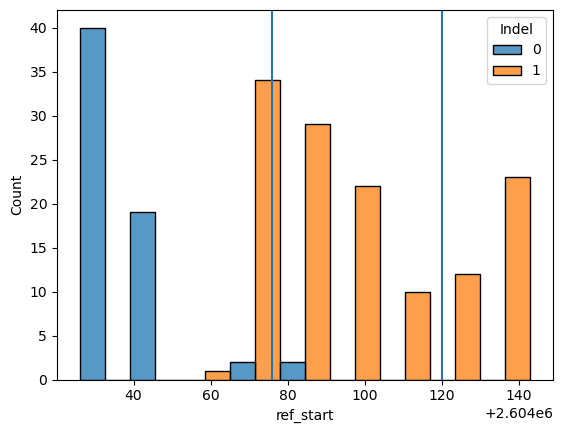

In [514]:
sns.histplot(data=df_reads_close_to_indel,
             x='ref_start',
             hue='Indel',
             # common_norm=False,
             multiple='dodge',
             # stat='probability'
            )

plt.axvline(Q1)
plt.axvline(Q3)

<Axes: xlabel='ref_end', ylabel='Count'>

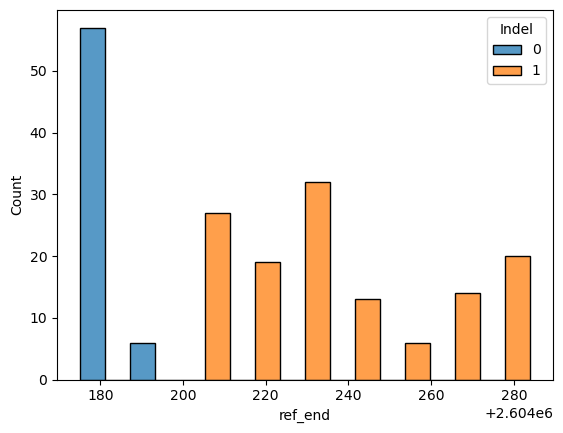

In [478]:
sns.histplot(data=df_reads_close_to_indel,
             x='ref_end',
             hue='Indel',
             # common_norm=False,
             multiple='dodge',
             # stat='probability'
            )

In [470]:
df_reads_close_to_indel.ref_start.min(), df_reads_close_to_indel.ref_start.max()

(2604026, 2604143)

In [457]:
df_benchmarking.loc[pd.isnull(df_benchmarking['POS'])].query("SampleID in @unmixed_lineage_samples").query("SampleID==@sample")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
0,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,0.487179,0.675258,MFS-310
1,NaN,NaN,NaN,NaN,NaN,NaN,4130651.0,G,GCACCGCCCGGCTGCGGCC,0.276316,0.502959,MFS-310


In [486]:
df_benchmarking.query("SampleID=='MFS-311'")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
0,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,0.524752,0.613636,MFS-311
1,NaN,NaN,NaN,NaN,NaN,NaN,4130651.0,G,GCACCGCCCGGCTGCGGCC,0.244094,0.491667,MFS-311


,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
1,1699255.0,ACT,C,108.0,201.0,0.537313,NaN,NaN,NaN,NaN,NaN,MFS-325
1,1699255.0,ACT,C,72.0,169.0,0.426036,NaN,NaN,NaN,NaN,NaN,MFS-326


In [269]:
df_benchmarking.loc[pd.isnull(df_benchmarking['H37Rv_POS'])].query("SampleID in @unmixed_lineage_samples")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
1,1699255.0,ACT,C,72.0,169.0,0.426036,NaN,NaN,NaN,NaN,NaN,MFS-326


In [270]:
df_benchmarking.loc[pd.isnull(df_benchmarking['POS'])].query("SampleID in @unmixed_lineage_samples")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
0,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.947368,0.944444,MFS-122
0,NaN,NaN,NaN,NaN,NaN,NaN,78973.0,GGGCATCC,G,0.890995,0.929487,MFS-132
1,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,0.506173,0.648069,MFS-132
1,NaN,NaN,NaN,NaN,NaN,NaN,2873093.0,G,GCCA,0.896552,0.878893,MFS-135
0,NaN,NaN,NaN,NaN,NaN,NaN,3462145.0,A,AGGCGC,0.917808,0.924138,MFS-136
2,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,0.509434,0.702970,MFS-160
3,NaN,NaN,NaN,NaN,NaN,NaN,3527948.0,AGCCGGCGTTTCCGAAGCCCGTGTTGGTGTC,A,0.310345,0.857143,MFS-160
0,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,0.581250,0.684444,MFS-173
0,NaN,NaN,NaN,NaN,NaN,NaN,3462145.0,A,AGGCGC,0.936508,0.932773,MFS-194
0,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAACAGTGCCAA,0.337838,0.670103,MFS-25


In [247]:
266/295

0.9016949152542373

In [160]:
df_benchmarking.loc[pd.isnull(df_benchmarking['POS'])].query("SampleID in @unmixed_lineage_samples").query("SampleID != 'MFS-326'").sort_values(['SampleID', 'POS']).query("SampleID in ['MFS-309', 'MFS-310']")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
0,NaN,NaN,NaN,NaN,NaN,NaN,552495.0,G,GCTA,0.767241,0.936508,MFS-309
1,NaN,NaN,NaN,NaN,NaN,NaN,3462145.0,A,AGGCGC,0.870130,0.923077,MFS-309
0,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,0.487179,0.675258,MFS-310
1,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.875000,0.933333,MFS-310
2,NaN,NaN,NaN,NaN,NaN,NaN,4130651.0,G,GCACCGCCCGGCTGCGGCC,0.276316,0.502959,MFS-310


In [173]:
df_indels_adj.columns

Index(['POS', 'REF', 'ALT', 'QUAL', 'FILTER', 'NS', 'DP', 'DPB', 'AC', 'AN',
       'AF', 'RO', 'AO', 'PRO', 'PAO', 'QR', 'QA', 'PQR', 'PQA', 'SRF', 'SRR',
       'SAF', 'SAR', 'SRP', 'SAP', 'AB', 'ABP', 'RUN', 'RPP', 'RPPR', 'RPL',
       'RPR', 'EPP', 'EPPR', 'DPRA', 'ODDS', 'GTI', 'TYPE', 'CIGAR', 'NUMALT',
       'MEANALT', 'LEN', 'MQM', 'MQMR', 'PAIRED', 'PAIREDR', 'MIN_DP', 'END',
       'ORIGIN', 'INV', 'Indel_Support', 'Total_Reads', 'AF_Adj'],
      dtype='object')

In [167]:
df_benchmarking.query("SampleID in @unmixed_lineage_samples")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
0,4314991.0,CG,C,17.0,320.0,0.053125,4314991.0,CG,C,0.053125,0.056856,MFS-1
0,2181090.0,CG,C,28.0,264.0,0.106061,2181090.0,CG,C,0.106061,0.103053,MFS-113
1,3093435.0,GC,G,14.0,207.0,0.067633,3093435.0,GC,G,0.067633,0.057895,MFS-113
0,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.947368,0.947368,MFS-122
0,4383592.0,CCGCGCCGCCGAG,C,43.0,211.0,0.203791,4383592.0,CCGCGCCGCCGAG,C,0.188406,0.296943,MFS-129
...,...,...,...,...,...,...,...,...,...,...,...,...
0,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,0.941176,0.857143,MFS-64
0,4369296.0,GC,G,10.0,194.0,0.051546,4369296.0,GC,G,0.051546,0.069519,MFS-65
0,1760164.0,T,TG,13.0,192.0,0.067708,1760164.0,T,TGGG,0.839623,0.862637,MFS-70
1,1760164.0,T,TG,13.0,192.0,0.067708,1760164.0,T,TGGGG,0.113208,0.123596,MFS-70


In [163]:
df_benchmarking.query("SampleID=='MFS-311'")

,POS,REF_x,ALT_x,AO,DP,AF_x,H37Rv_POS,REF_y,ALT_y,AF_y,AF_Adj,SampleID
0,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,0.524752,0.613636,MFS-311
1,NaN,NaN,NaN,NaN,NaN,NaN,4130651.0,G,GCACCGCCCGGCTGCGGCC,0.244094,0.491667,MFS-311


In [161]:
df_trust_patients.query("pid=='T0292'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
755,T0292,S0292-01,MFS-310,MFS-310_lib52351,NaN,NaN,1.0,310.12,0.99,0.9895,...,29.015,21.26,323.93,21.26,1B,0.0,18.57914,22.878014,401,NaN
756,T0292,S0292-08,MFS-311,MFS-311_lib52352,NaN,NaN,1.0,261.64,0.99,0.9869,...,29.015,21.26,323.93,21.26,1B,0.0,18.57914,22.878014,401,NaN


In [155]:
df_trust_patients.query("SampleID in ['MFS-309', 'MFS-310']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
751,T0291,S0291-09,MFS-309,MFS-309_lib52350,NaN,NaN,1.0,268.24,0.99,0.9853,...,13.300,14.514,304.56,10.422,1B,0.0,19.269424,24.837297,398,NaN
755,T0292,S0292-01,MFS-310,MFS-310_lib52351,NaN,NaN,1.0,310.12,0.99,0.9895,...,29.015,21.260,323.93,21.260,1B,0.0,18.579140,22.878014,401,NaN


In [129]:
def collapse_cigar_tuples(cigar_tuples):
    """
    Combine consecutive cigar operations with the same operator.
    Example:
        [('2', 'X'), ('3', 'M'), ('1', 'X'), ('2', 'X')] → [('2', 'X'), ('3', 'M'), ('3', 'X')]
    """
    
    df_cigar_tuples = pd.DataFrame(cigar_tuples, columns=['NumBases', 'Operator'])
    df_cigar_tuples['NumBases'] = df_cigar_tuples['NumBases'].astype(int)

    df_cigar_tuples_collapsed = pd.DataFrame(df_cigar_tuples.groupby('Operator')['NumBases'].sum()).reset_index()
    
    return [(row['NumBases'], row['Operator']) for i, row in df_cigar_tuples_collapsed.iterrows()]


def match_variant_to_cigar(ref, alt, cigar_string, collapse=True):
    
    # X = substitution, D = deletion, I = insertion
    if len(ref) == len(alt):
        aln_symbol = 'X'
    elif len(ref) > len(alt):
        aln_symbol = 'D'
    else:
        aln_symbol = 'I'
        
    if aln_symbol == 'X':
        variant_length = len(ref)
    else:
        variant_length = abs(len(ref) - len(alt))
        
    # convert CIGAR string to tuples
    cigar_tuples = re.findall(r"(\d+)([MIDNSHP=X])", cigar_string)
    
    # add numbers from the same operator, so 2X3M1X would be [('3', 'X'), ('3', 'M')]
    if collapse:
        cigar_tuples = collapse_cigar_tuples(cigar_tuples)
            
    match = False
    
    for num_bases, operator in cigar_tuples:
        if operator == aln_symbol and int(num_bases) == variant_length:
            return True, cigar_string
    
    return match, None

In [136]:
sample = 'MFS-162'
in_vcf = f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.split.vcf"

vcf_in = pysam.VariantFile(in_vcf)
# vcf_out = pysam.VariantFile(out_vcf, "w", header=vcf_in.header)

for record in vcf_in:

    new = record.copy()

    pos = record.pos
    ref = record.ref
    alt = record.alts
    depth = record.info['DP']
    ao = record.info['AO']
    mqm = record.info['MQM']
    meanAlt = record.info['MEANALT']
    saf = record.info['SAF']
    sar = record.info['SAR']
    
    # vcfwave splits multiallelics, so there should only be one ALT
    assert len(alt) == 1
    alt = alt[0]

    cigar_strings = list(record.info['CIGAR'])

    if len(cigar_strings) > 1 and len(ao) > 1:

        found_match = False

        for cigar_string in cigar_strings:
            found_match, matched_cigar = match_variant_to_cigar(ref, alt, cigar_string, collapse=True)

            if found_match:
                break

        # if no match was found after going through the collapsed versions, then check the uncollapsed cigar tuples.
        if not found_match:
            # the collapsed one is more accurate because of the problems of reporting multiple variants at different AFs on the same haplotype.
            # see 163705 and 163710 in MFS-172 for an example. 163705 is at high frequency, 163710 is at unfixed frequency
            for cigar_string in cigar_strings:
                found_match, matched_cigar = match_variant_to_cigar(ref, alt, cigar_string, collapse=False)

                if found_match:
                    break

        if found_match:
            keep_idx = list(cigar_strings).index(matched_cigar)
            print(pos, ref, alt, ao[keep_idx], depth)
        else:
            raise ValueError(pos, ref, alt, cigar_strings)            
            
        # get individual AO. If the index is longer than AO, then that variant is probably not real. So set AO = 0
        # need to also split MQM because we use that for filtering. For completeness, also split mean alt
        if len(ao) > keep_idx:
            new.info['AO'] = ao[keep_idx]
            new.info['MQM'] = mqm[keep_idx]
            new.info['MEANALT'] = meanAlt[keep_idx]
            new.info['SAF'] = saf[keep_idx]
            new.info['SAR'] = sar[keep_idx]
        else:
            new.info['AO'] = 0
            new.info['MQM'] = 0
            new.info['MEANALT'] = 0
            new.info['SAF'] = 0
            new.info['SAR'] = 0


162152 T G 4 213
162155 TT T 208 213
163705 CC TT 260 274
163710 C A 14 274
454332 GT CG 3 134
454333 T G 131 134
467635 T A 191 193
467638 G T 191 193
779615 G C 271 274
779619 T C 271 274
913181 G GG 160 264
913181 GCA G 3 264
1696672 A C 5 221
1696675 AA A 216 221
2273733 TC T 200 203
2273734 C T 3 203
2406842 AC A 226 232
2406843 C G 6 232
2551576 CT GC 257 260
2551577 T C 3 260
2564369 C CC 239 250
2564370 A C 8 250
2734481 TA T 223 227
2734482 A T 4 227
2796131 G C 3 111
2796138 C CC 106 111
2867880 TA T 218 224
2867881 A T 6 224
3473997 A AA 394 425
3473998 G A 24 425
3851887 AT CC 34 38
4379045 G C 4 223
4379048 GG G 219 223


In [131]:
ref = 'C'
alt = 'A'
cigar_string = '2X3M1X'

In [133]:
match_variant_to_cigar(ref, alt, cigar_string, collapse=False)

(True, '2X3M1X')

In [91]:
cigar_string

'1M1X6M'

In [92]:
found_match

False

In [22]:
ref = 'T'
alt = 'G'
cigar_string = '1M1D6M' #'1M1X6M' ##, 

match_variant_to_cigar(ref, alt, cigar_string)

False

In [ ]:
match_variant_to_cigar(162152, 'T', 'GG', '1M1D6M', ref_start)

In [14]:
df_benchmarking.query("H37Rv_POS==1699254 & SampleID=='MFS-326'")

,POS,REF_x,ALT_x,AO,DP,AF,H37Rv_POS,REF_y,ALT_y,AF_Adj,SampleID
4,NaN,NaN,NaN,NaN,NaN,NaN,1699254.0,G,GAC,0.595,MFS-326


In [1]:
134/224

0.5982142857142857

In [82]:
df_variants.query("POS==1333662")[['POS', 'REF', 'ALT', 'AF', 'IC', 'DC']]

,POS,REF,ALT,AF,IC,DC
93,1333662,G,.,0.0,22,0


In [84]:
ground_truth_indels[['POS', 'REF', 'ALT', 'AF']]

,POS,REF,ALT,AF
0,1333661,C,CG,0.070039
1,2468855,C,CA,0.221477
2,4408944,C,CCTGCCCGG,0.070769


In [56]:
df_benchmarking.loc[pd.isnull(df_benchmarking['POS'])].query("SampleID in @unmixed_lineage_samples")

,POS,REF_x,ALT_x,AO,DP,AF,H37Rv_POS,REF_y,ALT_y,SampleID
0,NaN,NaN,NaN,NaN,NaN,NaN,3480375.0,GA,G,MFS-106
0,NaN,NaN,NaN,NaN,NaN,NaN,4095001.0,CG,C,MFS-122
0,NaN,NaN,NaN,NaN,NaN,NaN,78973.0,GGGCATCC,G,MFS-132
1,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,MFS-132
1,NaN,NaN,NaN,NaN,NaN,NaN,2873093.0,G,GCCA,MFS-135
0,NaN,NaN,NaN,NaN,NaN,NaN,3462145.0,A,AGGCGC,MFS-136
2,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,MFS-160
0,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,MFS-172
0,NaN,NaN,NaN,NaN,NaN,NaN,2604156.0,T,TCAGTGCCAA,MFS-173
0,NaN,NaN,NaN,NaN,NaN,NaN,3462145.0,A,AGGCGC,MFS-194


In [ ]:
exclude_regions_file="/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed"

# vcfwave properly splits them, but misses splitting the AO field
vcfwave MFS-17.init.allHaps.vcf | bedtools subtract -a '-' -b $exclude_regions_file -header | bcftools sort > MFS-17.excludeLowConf.vcfwave.vcf

In [163]:
sample = 'MFS-17'
in_vcf = f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.vcfwave.vcf"
out_vcf = f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.vcfwave.fixedAO.vcf"

vcf_in = pysam.VariantFile(in_vcf)
vcf_out = pysam.VariantFile(out_vcf, "w", header=vcf_in.header)

for record in vcf_in:
    
    new = record.copy()
    
    pos = record.pos
    ref = record.ref
    alts = record.alts
    depth = record.info['DP']
    ao = record.info['AO']
    mqm = record.info['MQM']
    meanAlt = record.info['MEANALT']
    
    if record.id is not None and len(ao) > 1:
        
        # the ID column tells you the ordering of the variant in the AO field. The ID value is 1-indexed, so subtract 1
        keep_idx = int(','.join([char for char in record.id if char.isnumeric()])) - 1
        
        # vcfwave splits multiallelics, so there should only be one ALT
        assert len(alts) == 1
        
        # get individual AO. If the index is longer than AO, then that variant is probably not real. So set AO = 0
        # need to also split MQM because we use that for filtering. For completeness, also split mean alt
        if len(ao) > keep_idx:
            new.info['AO'] = ao[keep_idx]
            new.info['MQM'] = mqm[keep_idx]
            new.info['MEANALT'] = meanAlt[keep_idx]
        else:
            new.info['AO'] = 0
            new.info['MQM'] = 0
            new.info['MEANALT'] = 0

    vcf_out.write(new)

vcf_out.close()

In [144]:
out_vcf

'/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-17/freebayes/MFS-17.excludeLowConf.vcfwave.fixedAO.vcf'

In [141]:
# left-normalize indels. Don't do anything to multiallelics
bcftools norm '/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-17/freebayes/MFS-17.excludeLowConf.vcfwave.fixedAO.vcf' --fasta-ref $ref_genome > '/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-17/freebayes/MFS-17.excludeLowConf.vcfwave.fixedAO.norm.vcf'

echo -e "POS\nREF\nALT\nQUAL\nFILTER" > ~/field_names.txt
grep "^##INFO=<ID=" '/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-17/freebayes/MFS-17.excludeLowConf.vcfwave.fixedAO.norm.vcf' | cut -d'=' -f3 | cut -d',' -f1 >> ~/field_names.txt
# full TSV file, WITH the excluded regions          
SnpSift extractFields '/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-17/freebayes/MFS-17.excludeLowConf.vcfwave.fixedAO.norm.vcf' $(paste -sd " " ~/field_names.txt) > '/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-17/freebayes/MFS-17.excludeLowConf.vcfwave.fixedAO.tsv'

(2, 134)

In [172]:
df_test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-17/freebayes/MFS-17.excludeLowConf.vcfwave.fixedAO.tsv", sep='\t')

df_test['AF'] = df_test['AO'] / df_test['DP']

In [173]:
df_test.query("AF >= @AF_min & AF <= @AF_max & REF.str.len() != ALT.str.len() & MQM >= 40")

,POS,REF,ALT,QUAL,FILTER,NS,DP,DPB,AC,AN,...,MEANALT,LEN,MQM,MQMR,PAIRED,PAIREDR,MIN_DP,END,ORIGIN,INV
416,968426,A,AGCCGGGTTG,4000.0,NaN,1,191,321.091,1,1,...,2.0,9,60.0,59.2258,1.0,1.0,NaN,NaN,Chromosome:968426,False
594,1333661,C,CG,7200.0,NaN,1,256,258.182,0,1,...,2.0,1,60.0,0.0000,"1,1",0.0,NaN,NaN,Chromosome:1333661,False
636,1418863,C,CGGGAGCCA,4300.0,NaN,1,225,369.800,1,1,...,1.0,8,60.0,59.8182,1.0,1.0,NaN,NaN,Chromosome:1418863,False
813,1894300,G,GGTCTTGCCGC,3800.0,NaN,1,140,570.000,1,1,...,3.0,10,60.0,0.0000,0.992248,0.0,NaN,NaN,Chromosome:1894300,False
903,2153725,CTCATCCCCGTCTCG,C,2800.0,NaN,1,164,52.125,1,1,...,1.0,14,60.0,60.0000,0.984375,1.0,NaN,NaN,Chromosome:2153725,False
1027,2358029,T,TG,6200.0,NaN,1,221,263.200,1,1,...,3.0,1,60.0,0.0000,1.0,0.0,NaN,NaN,Chromosome:2358029,False
1077,2468855,C,CA,0.0,NaN,1,300,322.333,0,1,...,2.0,1,60.0,60.0000,1.0,1.0,NaN,NaN,Chromosome:2468855,False
1107,2564368,G,GC,8600.0,NaN,1,311,405.000,1,1,...,3.0,1,60.0,0.0000,"1,1",0.0,NaN,NaN,Chromosome:2564368,False
1340,3131469,T,TTGTCGGCGA,4100.0,NaN,1,269,848.000,1,1,...,2.0,9,60.0,60.0000,1.0,1.0,NaN,NaN,Chromosome:3131469,False
1388,3296371,G,GCCGCGGC,5200.0,NaN,1,204,350.556,1,1,...,2.0,7,60.0,60.0000,1.0,1.0,NaN,NaN,Chromosome:3296371,False


In [174]:
ground_truth_indels

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,1333661,C,CG,2.700000e-14,NaN,257,239,18,0.070039,60.0,...,139,100,14,4,16.82960,15.07400,20.3821,16.8296,3.0,15.0
1,2468855,C,CA,0.000000e+00,NaN,298,227,66,0.221477,60.0,...,114,113,34,32,3.01987,3.14190,13.6703,17.5601,42.0,24.0
2,4408944,C,CCTGCCCGG,1.200000e-14,NaN,325,302,23,0.070769,60.0,...,146,156,12,11,3.72933,3.10471,5.3706,27.1985,9.0,14.0


In [98]:
sample = 'MFS-17'
in_vcf = f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.init.allHaps.vcf"
out_vcf = f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.allHaps.fixedAO.vcf"

vcf_in = pysam.VariantFile(in_vcf)
vcf_out = pysam.VariantFile(out_vcf, "w", header=vcf_in.header)

for rec in vcf_in:
    alts = rec.alts or []
    ao = rec.info.get('AO')
    type_field = rec.info.get('TYPE')

    for i, alt in enumerate(alts):
        new = rec.copy()
        new.alts = (alt,)

        # Split AO if available
        if ao and len(ao) == len(alts):
            new.info['AO'] = (ao[i],)

        # Determine variant type
        if type_field and len(type_field) == len(alts):
            new_type = type_field[i]
        elif type_field and len(type_field) == 1:
            new_type = type_field[0]
        else:
            new_type = None

        # If it's "complex", infer indel direction
        if new_type == "complex" or new_type == "indel" or new_type is None:
            ref_len = len(rec.ref)
            alt_len = len(alt)
            if alt_len > ref_len:
                new_type = "ins"
            elif alt_len < ref_len:
                new_type = "del"
            else:
                new_type = "snp"

        new.info['TYPE'] = (new_type,)

        vcf_out.write(new)

vcf_out.close()

In [ ]:
ref_genome="/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/ref_genome/H37Rv_NC_000962.3.fna"

bcftools norm --multiallelics -both MFS-17.allHaps.vcfwave.fixedAO.vcf --fasta-ref $ref_genome > MFS-17.allHaps.vcfwave.fixedAO.split.vcf

In [85]:
len("CGGGGGGGGCT")

11

In [86]:
len("CGGGGGGGTCT")

11

In [64]:
df_benchmarking.loc[pd.isnull(df_benchmarking['H37Rv_POS'])].query("SampleID in @unmixed_lineage_samples")

,POS,REF_x,ALT_x,AO,DP,AF,H37Rv_POS,REF_y,ALT_y,AF_Adj,SampleID
0,1333661.0,C,CG,18.0,257.0,0.070039,NaN,NaN,NaN,NaN,MFS-17


In [169]:
sample = 'MFS-17'

ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv").query("AF >= @AF_min & AF <= @AF_max")
ground_truth_indels = ground_truth.query("REF.str.len() != ALT.str.len()").reset_index(drop=True)

# df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_variants.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")

In [171]:
ground_truth_indels

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,1333661,C,CG,2.700000e-14,NaN,257,239,18,0.070039,60.0,...,139,100,14,4,16.82960,15.07400,20.3821,16.8296,3.0,15.0
1,2468855,C,CA,0.000000e+00,NaN,298,227,66,0.221477,60.0,...,114,113,34,32,3.01987,3.14190,13.6703,17.5601,42.0,24.0
2,4408944,C,CCTGCCCGG,1.200000e-14,NaN,325,302,23,0.070769,60.0,...,146,156,12,11,3.72933,3.10471,5.3706,27.1985,9.0,14.0


In [61]:
pd.DataFrame({'A': ['MFS-17'], 'B': ['MFS-17'], 'C': [0]}).to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/TRUST_samples_to_run.tsv", sep='\t', header=None, index=False)

In [36]:
sample = 'MFS-106'

ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv").query("AF >= @AF_min & AF <= @AF_max")
ground_truth_indels = ground_truth.query("REF.str.len() != ALT.str.len()").reset_index(drop=True)

df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")

# keep only low frequency variants. Extract fixed variants separately
df_variants = apply_freebayes_lowAF_QCfilters(df_variants, AF_min=AF_min, AF_max=AF_max)

df_indels = df_variants.query("REF.str.len() != ALT.str.len()")

df_confusion_matrix = ground_truth_indels[['POS', 'REF', 'ALT', 'AO', 'DP', 'AF']]


In [38]:
df_indels[['POS', 'REF', 'ALT', 'AO', 'DP', 'AF']]

,POS,REF,ALT,AO,DP,AF
0,968426,A,AGCCGGGTTG,109,138,0.789855
4,3131469,T,TTGTCGGCGA,157,208,0.754808
5,3473996,G,GA,250,266,0.939850
7,3480375,GA,G,9,120,0.075000


In [44]:
pos = 3480375
ref = 'GA'
alt = 'G'
chrom = 'Chromosome'
dist_from_indel = 10
bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"
bam = pysam.AlignmentFile(bam_file, "rb")

indel_length = abs(len(ref) - len(alt))

if len(alt) > len(ref):
    search_string = 'I'
    search_val = 1
else:
    search_string = 'D'
    search_val = 2

reads_overlapping = []

for read in bam.fetch(chrom, pos - 1, pos):  # pysam uses 0-based, half-open

    if read.cigarstring is not None:

        indel_cigar_length = sum(length for (op, length) in (read.cigartuples or []) if op == search_val and length == indel_length)

        # get number of bases soft clipped from this read
        num_soft_clipped_bases = sum(length for (op, length) in (read.cigartuples or []) if op == 4)

        reads_overlapping.append({
            "read_name": read.query_name,
            "ref_start": read.reference_start + 1,  # make it 1-based
            "ref_end": read.reference_end,
            "num_indel": indel_cigar_length,
            "num_soft_clipped": num_soft_clipped_bases,
            "cigar": read.cigarstring,
            "cigartuples": read.cigartuples,
        })

df_overlapping_reads = pd.DataFrame(reads_overlapping)

# include a read only if neither its start nor end are within 10 base pairs of the indel site
df_reads_close_to_indel = df_overlapping_reads.loc[(abs(df_overlapping_reads['ref_start'] - pos) >= dist_from_indel) & 
                                                   (abs(df_overlapping_reads['ref_end'] - pos) >= dist_from_indel)
                                                  ]

# # also exclude reads that start or end in the middle of the indel            
# # this position is inclusive. So the read must not have a start or end within this
# indel_end = pos + indel_length

# df_reads_close_to_indel = df_reads_close_to_indel.loc[~((df_reads_close_to_indel['ref_start'] >= pos) & (df_reads_close_to_indel['ref_start'] <= indel_end))]

# df_reads_close_to_indel = df_reads_close_to_indel.loc[~((df_reads_close_to_indel['ref_end'] >= pos) & (df_reads_close_to_indel['ref_end'] <= indel_end))]

# # AND include a read only if neither its start nor end are within 10 base pairs of the deletion END
# df_reads_close_to_indel = df_reads_close_to_indel.loc[(abs(df_reads_close_to_indel['ref_start'] - indel_end) >= dist_from_indel) & 
#                                                       (abs(df_reads_close_to_indel['ref_end'] - indel_end) >= dist_from_indel)
#                                                      ]


# # AND exclude reads with ANY soft clipping from contributing to the depth
# df_reads_close_to_indel = df_reads_close_to_indel.query("num_soft_clipped == 0")


In [47]:
pos

3480375

In [46]:
df_overlapping_reads

,read_name,ref_start,ref_end,num_indel,num_soft_clipped,cigar,cigartuples
0,VH00503:10:AAC2NY5M5:1:2402:18932:54859,3480225,3480375,0,0,151M,"[(0, 151)]"
1,VH00503:10:AAC2NY5M5:1:1204:21696:42706,3480226,3480376,0,0,151M,"[(0, 151)]"
2,VH00503:10:AAC2NY5M5:1:2103:41522:16713,3480226,3480376,0,0,151M,"[(0, 151)]"
3,VH00503:10:AAC2NY5M5:1:2103:69887:32805,3480226,3480376,0,0,151M,"[(0, 151)]"
4,VH00503:10:AAC2NY5M5:1:1103:12759:20594,3480226,3480375,0,0,150M,"[(0, 150)]"
...,...,...,...,...,...,...,...
134,VH00503:10:AAC2NY5M5:1:2404:17587:41437,3480371,3480484,0,34,34S114M,"[(4, 34), (0, 114)]"
135,VH00503:10:AAC2NY5M5:1:1204:42033:51565,3480373,3480523,0,0,151M,"[(0, 151)]"
136,VH00503:10:AAC2NY5M5:1:2302:69812:52114,3480374,3480524,0,0,151M,"[(0, 151)]"
137,VH00503:10:AAC2NY5M5:1:1202:67464:47495,3480374,3480523,0,0,150M,"[(0, 150)]"


In [45]:
df_reads_close_to_indel

,read_name,ref_start,ref_end,num_indel,num_soft_clipped,cigar,cigartuples


In [34]:
sample = 'MFS-106'

pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv").query("AF >= @AF_min & AF <= @AF_max")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,1271358,A,G,0.000000e+00,NaN,195,185,10,0.051282,60.0000,...,38,147,5,5,142.46600,3.01030,6.48466,19.07920,7.0,3.0
1,1375214,C,T,6.500000e-14,NaN,230,130,100,0.434783,60.0000,...,73,57,49,51,7.28643,3.09716,11.69620,22.31970,40.0,60.0
2,1707552,G,C,0.000000e+00,NaN,263,148,115,0.437262,59.9565,...,74,74,67,48,3.01030,9.82684,4.53977,5.12308,53.0,62.0
3,3519019,G,C,0.000000e+00,NaN,291,217,74,0.254296,60.0000,...,105,112,41,33,3.50063,4.88833,4.06669,10.30520,34.0,40.0
4,4224645,C,G,0.000000e+00,NaN,282,225,57,0.202128,60.0000,...,90,135,18,39,22.55360,19.81060,3.96270,4.17807,31.0,26.0
5,4256605,G,A,1.200000e-14,NaN,265,221,44,0.166038,60.0000,...,108,113,20,24,3.25594,3.79993,7.94546,8.20808,27.0,17.0


In [27]:
df_benchmarking

,POS,REF_x,ALT_x,AO,DP,AF,REF_y,ALT_y
0,4314991,CG,C,17,320,0.053125,CG,C


In [301]:
df_candidate_unfixed_indels_adjusted_AF.query("AF_Adj <= 0.95")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj


In [138]:
ground_truth

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,2076862,A,G,5.500000e-14,NaN,262,241,21,0.080153,60.0,...,116,125,9,12,3.74013,3.94093,3.1137,19.67030,10.0,11.0
1,4314991,CG,C,4.100000e-14,NaN,320,302,17,0.053125,60.0,...,205,97,9,8,86.87800,3.13803,4.1599,5.88642,7.0,10.0


In [124]:
df_candidate_unfixed_indels_adjusted_AF.query("AF_Adj <= 0.98").merge(df_soft_clips, on='POS')

,POS,REF,ALT,AF,AF_Adj,CHROM,CLIPPED_BASES
0,33207,G,GGC,0.905455,0.979592,Chromosome,3
1,472711,T,TTTGTGGGCC,0.843284,0.911565,Chromosome,44
2,1042692,T,TCTTGTTCACCCAGTACCTGTCCAA,0.978723,0.753846,Chromosome,120
3,1418863,C,CGGGAGCCA,0.750000,0.968000,Chromosome,37
4,3296371,G,GCCGCGGC,0.883117,0.968254,Chromosome,19
5,4314991,CG,C,0.053125,0.030612,Chromosome,0


297/333 at position 33207 support an insertion


In [ ]:
df_overlapping_reads

In [79]:
297/333

0.8918918918918919

In [80]:
df_overlapping_reads.ref_start.min(), df_overlapping_reads.ref_end.max()

(33057, 33357)

96/98 at position 33207 support an insertion


In [88]:
96/98

0.9795918367346939

<Axes: xlabel='ref_start', ylabel='num_ins'>

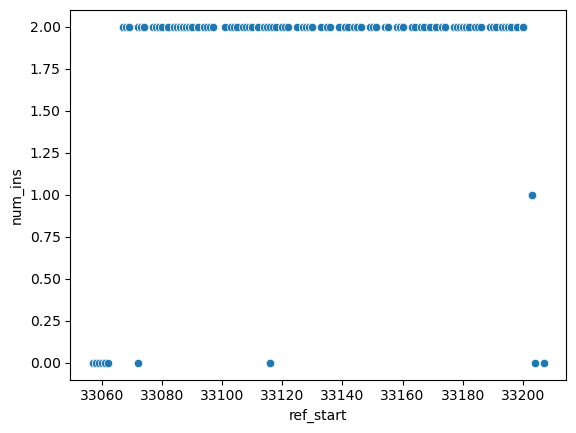

In [70]:
sns.scatterplot(data=df_overlapping_reads,
                x='ref_start',
                y='num_ins'
               )

In [61]:
ins_size

2

In [53]:
df_overlapping_reads.query("cigar.str.contains('I
                           ')")

,read_name,ref_start,ref_end,cigar,cigartuples
26,VH00503:3:AAAVJLNM5:1:1202:15675:51868,33067,33214,141M2I7M,"[(0, 141), (1, 2), (0, 7)]"
27,VH00503:3:AAAVJLNM5:1:2303:26923:46719,33067,33214,141M2I7M,"[(0, 141), (1, 2), (0, 7)]"
28,VH00503:3:AAAVJLNM5:1:2304:46369:4483,33067,33214,141M2I7M,"[(0, 141), (1, 2), (0, 7)]"
29,VH00503:3:AAAVJLNM5:1:1301:39231:13438,33068,33215,140M2I8M,"[(0, 140), (1, 2), (0, 8)]"
30,VH00503:3:AAAVJLNM5:1:2301:32452:47893,33068,33215,140M2I8M,"[(0, 140), (1, 2), (0, 8)]"
...,...,...,...,...,...
321,VH00503:3:AAAVJLNM5:1:2203:28097:26955,33203,33351,5M1I144M,"[(0, 5), (1, 1), (0, 144)]"
322,VH00503:3:AAAVJLNM5:1:2401:25162:42724,33203,33330,5M1I123M21S,"[(0, 5), (1, 1), (0, 123), (4, 21)]"
323,VH00503:3:AAAVJLNM5:1:2402:26809:47855,33203,33351,5M1I144M,"[(0, 5), (1, 1), (0, 144)]"
324,VH00503:3:AAAVJLNM5:1:2403:73788:45753,33203,33351,5M1I144M,"[(0, 5), (1, 1), (0, 144)]"


In [42]:
df_overlapping_reads.query("cigar.str.contains('I')")

,read_name,ref_start,ref_end,cigar,cigartuples
26,VH00503:3:AAAVJLNM5:1:1202:15675:51868,33067,33214,141M2I7M,"[(0, 141), (1, 2), (0, 7)]"
27,VH00503:3:AAAVJLNM5:1:2303:26923:46719,33067,33214,141M2I7M,"[(0, 141), (1, 2), (0, 7)]"
28,VH00503:3:AAAVJLNM5:1:2304:46369:4483,33067,33214,141M2I7M,"[(0, 141), (1, 2), (0, 7)]"
29,VH00503:3:AAAVJLNM5:1:1301:39231:13438,33068,33215,140M2I8M,"[(0, 140), (1, 2), (0, 8)]"
30,VH00503:3:AAAVJLNM5:1:2301:32452:47893,33068,33215,140M2I8M,"[(0, 140), (1, 2), (0, 8)]"
...,...,...,...,...,...
321,VH00503:3:AAAVJLNM5:1:2203:28097:26955,33203,33351,5M1I144M,"[(0, 5), (1, 1), (0, 144)]"
322,VH00503:3:AAAVJLNM5:1:2401:25162:42724,33203,33330,5M1I123M21S,"[(0, 5), (1, 1), (0, 123), (4, 21)]"
323,VH00503:3:AAAVJLNM5:1:2402:26809:47855,33203,33351,5M1I144M,"[(0, 5), (1, 1), (0, 144)]"
324,VH00503:3:AAAVJLNM5:1:2403:73788:45753,33203,33351,5M1I144M,"[(0, 5), (1, 1), (0, 144)]"


In [2]:
df_trust_patients.query("pid=='T0033'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
704,T0033,S0033-01,MFS-18,MFS-18_lib45948,NaN,NaN,1.0,375.92,0.99,0.9873,...,34.84,22.283,356.03,22.283,1B,1.0,14.470969,21.497438,370,NaN
705,T0033,S0033-05,MFS-19,MFS-19_lib45949,NaN,NaN,1.0,393.71,0.99,0.9863,...,34.84,22.283,356.03,22.283,1B,1.0,14.470969,21.497438,370,NaN


In [3]:
df_candidate_SNPs_ground_truth.query("POS==2737572")[['SampleID', 'Real']]

NameError: name 'df_candidate_SNPs_ground_truth' is not defined

In [ ]:
# samples_lst = df_trust_patients.query("F2 > 0.03").SampleID.values

# df_mixed = pd.DataFrame({'A': samples_lst, 'B': samples_lst, 'C': [1]*len(samples_lst)})

# df_mixed.to_csv("../TRUST_highF2_samples.tsv", sep='\t', header=None, index=False)

# Get the SNP Input data

In [22]:
# samples_lst = ['MFS-839', 'MFS-841', 'MFS-424', 'MFS-481', 'MFS-668', 'MFS-1', 'MFS-767', 'MFS-853', 'MFS-127', 'MFS-21', 'MFS-546', 'MFS-790', 'MFS-10']
# for sample in samples_lst:
#     if os.path.isfile(f"{H37Rv_ref_dir}/{sample}/freebayes/fixed_SNPs.csv"):
#         os.remove(f"{H37Rv_ref_dir}/{sample}/freebayes/fixed_SNPs.csv")
#     else:
#         print(sample)
        
#     shutil.copy2(f"{H37Rv_ref_dir}/{sample}/freebayes/.snapshot/data1_2025-10-30_17_20_04_UTC/fixed_SNPs.csv", f"{H37Rv_ref_dir}/{sample}/freebayes/fixed_SNPs.csv")

In [5]:
len(unmixed_lineage_samples), len(mixed_lineage_samples)

(709, 28)

In [16]:
df_candidate_SNPs.query("POS==2591484").False_in_all_Ground_Truth_Samples.unique()

array([1])

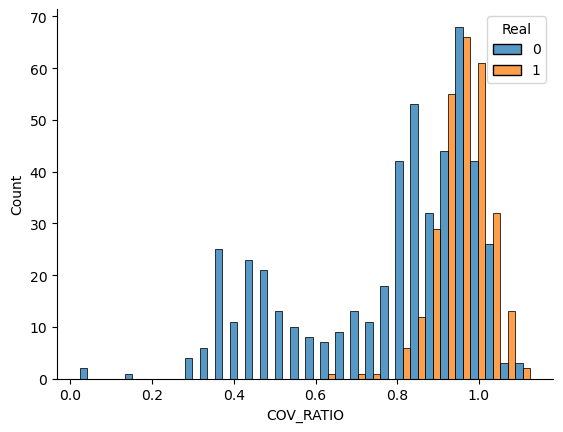

In [28]:
sns.histplot(data=df_candidate_SNPs_ground_truth,
             x='COV_RATIO',
             hue='Real',
             multiple='dodge'
            )

sns.despine()

In [27]:
df_candidate_SNPs_ground_truth.query("POS==2591484")[['COV_RATIO', 'Real']]

,COV_RATIO,Real
1,0.956306,0
18,0.929238,0
31,0.968929,0
40,0.993410,0
47,0.955621,0
54,0.947034,0
63,0.937864,0
70,0.966184,0
77,0.966074,0
85,0.984419,0


In [28]:
model_dir = "model_2_mixed_lineage/"

df_real_variants = pd.read_csv(f"{model_dir}/training_data.csv")
df_val_predictions = pd.read_csv(f"{model_dir}/linear_mixed_model_predictions.csv")

In [30]:
df_real_variants.AF.min(), df_real_variants.AF.max()

(0.05, 0.9497907949790796)

In [5]:
df_val_predictions.AF.min(), df_val_predictions.AF.max()

(0.05, 0.95)

<Axes: xlabel='AF', ylabel='Count'>

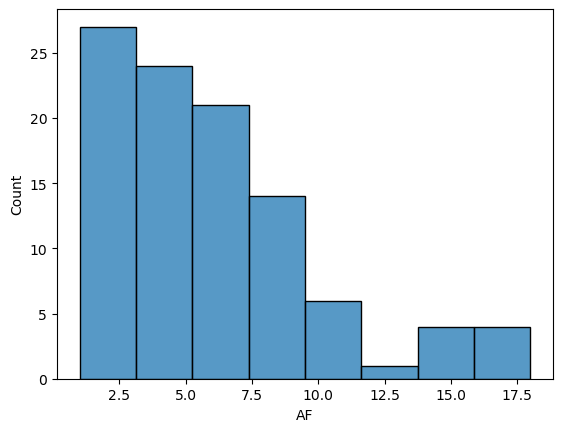

In [53]:
df_variants_training_set = pd.DataFrame(df_real_variants.query("F2 <= @F2_max").groupby('SampleID')['AF'].count()).reset_index()

sns.histplot(data=df_variants_training_set,
             x='AF'
            )

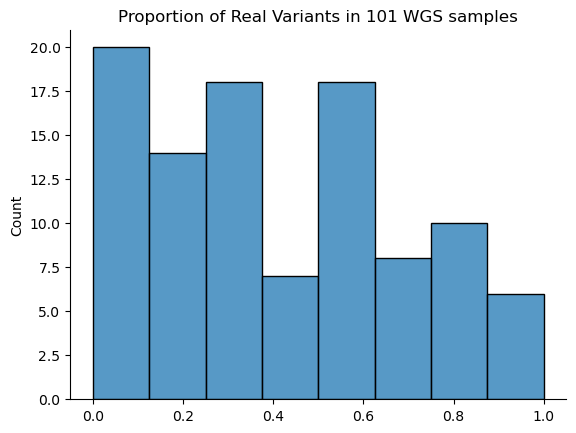

In [58]:
df_prop_real_variants = pd.DataFrame(df_real_variants.query("F2 <= @F2_max").groupby('SampleID').Real.mean()).reset_index()

sns.histplot(data=df_prop_real_variants,
             x='Real'
            )

plt.title(f'Proportion of Real Variants in {df_prop_real_variants.SampleID.nunique()} WGS samples')
plt.xlabel('')

sns.despine()
plt.savefig("../../results/figures/ground_truth_variants_proportion_real.svg", bbox_inches='tight')

In [26]:
df_variants_per_sample = pd.DataFrame(df_val_predictions.groupby('SampleID')['AF'].count()).reset_index()
df_variants_per_sample_after_exclusion = pd.DataFrame(df_val_predictions.query("pred_class==1").groupby('SampleID')['AF'].count()).reset_index()

df_variants_per_sample = df_variants_per_sample.rename(columns={'AF': 'NumVar'}).merge(df_variants_per_sample_after_exclusion.rename(columns={'AF': 'Num_highQual_Var'}))

df_variants_per_sample['Diff'] = df_variants_per_sample['NumVar'] - df_variants_per_sample['Num_highQual_Var']

<Axes: xlabel='NumVar', ylabel='Num_highQual_Var'>

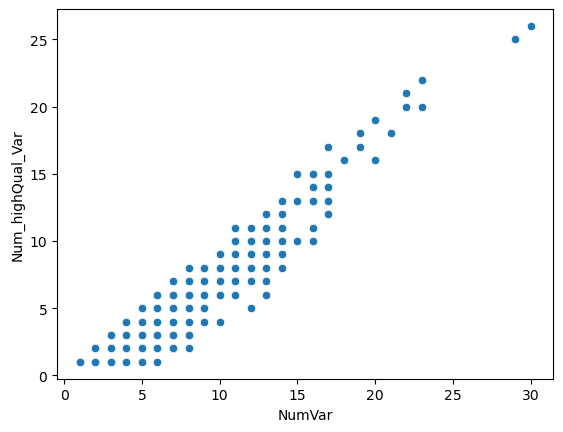

In [27]:
sns.scatterplot(data=df_variants_per_sample.query("SampleID in @unmixed_lineage_samples"),
                x='NumVar',
                y='Num_highQual_Var'
               )

<Axes: xlabel='Diff', ylabel='Count'>

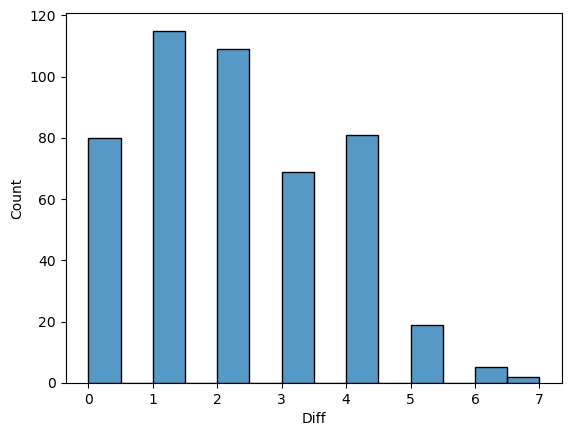

In [25]:
sns.histplot(data=df_variants_per_sample.query("SampleID in @unmixed_lineage_samples"),
             x='Diff'
            )

In [5]:
model_dir = "model_2_mixed_lineage/"

df_fixed_predictions = pd.read_csv(f"{model_dir}/fixed_variants_with_predictions.csv")

df_train_predictions = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")

df_val_predictions = pd.read_csv(f"{model_dir}/linear_mixed_model_predictions.csv")

In [33]:
df_fixed_predictions.loc[df_fixed_predictions['ANN.0..GENE']=='phoP'].query("pid=='T0294'")[['POS', 'REF', 'ALT', 'AF', 'predicted', 'pred_class']]

,POS,REF,ALT,AF,predicted,pred_class
81365,851701,A,G,0.957831,0.011285,0


In [36]:
len(df_fixed_predictions.query("pred_class==0")) / len(df_fixed_predictions)

0.01955974790543963

In [56]:
df_fixed_predictions.query("POS==1849 & SampleID=='MFS-17'")

,POS,REF,ALT,QUAL,FILTER,ANN.0..GENE,ANN.0..HGVS_C,ANN.0..HGVS_P,NS,DP,...,SampleID,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,False_in_all_Ground_Truth_Samples,predicted,pred_class
73404,1849,C,A,13537.0,NaN,dnaA-dnaN,n.1849C>A,NaN,1,445,...,MFS-17,T0031,2.2.1,2.2.1.1.1,2,0.010082,0.075281,0,0.201273,0


In [7]:
df_prop_predicted_real_fixed_variants = pd.DataFrame(columns = ['SampleID', 'PropReal'])

for i, sample in enumerate(df_fixed_predictions.query("pid in @pids_with_same_lineage_and_low_F2").SampleID.unique()):
    df_prop_predicted_real_fixed_variants.loc[i, :] = [sample, df_fixed_predictions.query("SampleID==@sample").pred_class.mean()]

In [9]:
df_prop_predicted_real_fixed_variants.sort_values('PropReal')

,SampleID,PropReal
480,MFS-81,0.954481
53,MFS-162,0.955335
394,MFS-674,0.956803
67,MFS-182,0.956954
92,MFS-267,0.956958
...,...,...
450,MFS-755,0.998737
496,MFS-833,0.998773
511,MFS-850,1.0
465,MFS-779,1.0


In [13]:
df_val_predictions.loc[df_val_predictions['ANN.0..GENE']=='phoP'].query("pid=='T0294'")[['POS', 'REF', 'ALT', 'AF']]

,POS,REF,ALT,AF
2921,851701,A,G,0.6121


In [14]:
fixed_variants = pd.read_csv(f"{model_dir}/fixed_variants.csv")

In [19]:
fixed_variants.loc[fixed_variants['ANN[0].GENE']=='phoP'].query("pid=='T0294'")[['POS', 'REF', 'ALT', 'AF']]

,POS,REF,ALT,AF
81365,851701,A,G,0.957831


In [23]:
fixed_variants.query("pid in @df_val_predictions.pid")

,POS,REF,ALT,QUAL,FILTER,ANN[0].GENE,ANN[0].HGVS_C,ANN[0].HGVS_P,NS,DP,...,CLIPPED_BASES_RATIO,SampleID,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,Real,False_in_all_Ground_Truth_Samples
113,2258008,T,C,5200.0,NaN,Rv2008c-vapB15,n.2258008T>C,NaN,1.0,180.0,...,0.261780,MFS-44,T0077,4.1.2.1,4.1.i1.1.1.1,4,0.021498,0.000000,0.0,0
114,2258010,G,C,5200.0,NaN,Rv2008c-vapB15,n.2258010G>C,NaN,1.0,180.0,...,0.261780,MFS-44,T0077,4.1.2.1,4.1.i1.1.1.1,4,0.021498,0.000000,0.0,0
115,2258017,C,T,5200.0,NaN,Rv2008c-vapB15,n.2258017C>T,NaN,1.0,180.0,...,0.340426,MFS-44,T0077,4.1.2.1,4.1.i1.1.1.1,4,0.021498,0.000000,0.0,0
116,2380148,A,G,1100.0,NaN,hisG,c.513T>C,p.Gly171Gly,1.0,40.0,...,0.021277,MFS-44,T0077,4.1.2.1,4.1.i1.1.1.1,4,0.021498,0.166667,0.0,0
153,1742,G,A,13235.0,NaN,dnaA-dnaN,n.1742G>A,NaN,1.0,435.0,...,0.008368,MFS-10,T0021,4.3.2.1,4.2.1.2.1.1.i1,4,0.009122,0.005747,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581258,4386709,C,T,8100.0,NaN,Rv3901c,c.106G>A,p.Ala36Thr,1.0,266.0,...,0.000000,MFS-99,T0181,4.1.1.3,4.1.i1.2.1,4,0.018140,0.018797,NaN,0
581259,4393178,A,G,8100.0,NaN,pcnA-mutT4,n.4393178A>G,NaN,1.0,265.0,...,0.000000,MFS-99,T0181,4.1.1.3,4.1.i1.2.1,4,0.018140,0.024528,NaN,0
581260,4400246,G,A,7200.0,NaN,sigM,c.61G>A,p.Asp21Asn,1.0,238.0,...,0.007220,MFS-99,T0181,4.1.1.3,4.1.i1.2.1,4,0.018140,0.016807,NaN,0
581261,4404874,G,A,8600.0,NaN,Rv3916c,c.294C>T,p.Thr98Thr,1.0,284.0,...,0.006452,MFS-99,T0181,4.1.1.3,4.1.i1.2.1,4,0.018140,0.070423,NaN,0


In [22]:
df_train

,POS,REF,ALT,QUAL,FILTER,ANN[0].GENE,ANN[0].HGVS_C,ANN[0].HGVS_P,NS,DP,...,CLIPPED_BASES_RATIO,SampleID,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,Real,False_in_all_Ground_Truth_Samples
0,2076862,A,G,5.500000e-14,NaN,gcvB,c.986A>G,p.Lys329Arg,1.0,262.0,...,0.003663,MFS-1,T0004,2.2.1.1,2.2.1.1.1,2,0.011212,0.071429,1,0
1,2591484,G,A,6.100000e+02,NaN,uspC,c.967G>A,p.Gly323Ser,1.0,480.0,...,0.008224,MFS-1,T0004,2.2.1.1,2.2.1.1.1,2,0.011212,0.168000,0,0
2,2592310,G,A,2.100000e+03,NaN,Rv2319c,c.417C>T,p.Ile139Ile,1.0,485.0,...,0.001887,MFS-1,T0004,2.2.1.1,2.2.1.1.1,2,0.011212,0.078755,0,0
3,3851887,A,C,9.500000e+02,NaN,Rv3433c,c.1326_1327delATinsGG,p.Ser443Ala,1.0,42.0,...,1.071429,MFS-1,T0004,2.2.1.1,2.2.1.1.1,2,0.011212,0.397436,0,1
4,3851888,T,C,9.500000e+02,NaN,Rv3433c,c.1326_1327delATinsGG,p.Ser443Ala,1.0,42.0,...,1.071429,MFS-1,T0004,2.2.1.1,2.2.1.1.1,2,0.011212,0.397436,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3970,1844169,G,T,0.000000e+00,NaN,uvrA,c.429G>T,p.Met143Ile,1.0,331.0,...,0.002817,MFS-97,T0180,2.2.1.1,2.2.1.1.1,2,0.010201,0.000000,1,0
3971,2591484,G,A,0.000000e+00,NaN,uspC,c.967G>A,p.Gly323Ser,1.0,475.0,...,0.000000,MFS-97,T0180,2.2.1.1,2.2.1.1.1,2,0.010201,0.207207,0,0
3972,2592310,G,A,3.000000e+03,NaN,Rv2319c,c.417C>T,p.Ile139Ile,1.0,502.0,...,0.003650,MFS-97,T0180,2.2.1.1,2.2.1.1.1,2,0.010201,0.055556,0,0
3973,3851887,A,C,3.600000e+03,NaN,Rv3433c,c.1326_1327delATinsGG,p.Ser443Ala,1.0,130.0,...,0.125000,MFS-97,T0180,2.2.1.1,2.2.1.1.1,2,0.010201,0.044715,0,1


In [50]:
df_candidate_SNPs_ground_truth.query("POS==163705 & SampleID=='MFS-58'")

,POS,REF,ALT,QUAL,FILTER,ANN[0].GENE,ANN[0].HGVS_C,ANN[0].HGVS_P,NS,DP,...,CLIPPED_BASES_RATIO,SampleID,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,Real,False_in_all_Ground_Truth_Samples
4012,163705,C,T,7900.0,NaN,cyp138,c.340_341delCCinsTT,p.Pro114Phe,1.0,280.0,...,0.039216,MFS-58,T0107,2.2.1.1,2.2.1.1.1,2,0.01008,0.15283,0,0


In [49]:
df_val_predictions.query("POS==163705 & SampleID=='MFS-58'")

,POS,REF,ALT,QUAL,FILTER,ANN.0..GENE,ANN.0..HGVS_C,ANN.0..HGVS_P,NS,DP,...,SampleID,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,False_in_all_Ground_Truth_Samples,predicted,pred_class


In [38]:
df_candidate_SNPs_ground_truth.AF.min(), df_val.AF.min()

(0.05, 0.05)

In [122]:
sample = 'MFS-317'
missed_pos = df_candidate_SNPs_ground_truth.loc[pd.isnull(df_candidate_SNPs_ground_truth['COV_RATIO'])].query("SampleID==@sample").POS.values
len(missed_pos)

0

In [128]:
df_LR_assembly_metadata.columns

Index(['SampleID', 'NumContigs', 'numContigs_Complete', 'circContig_Length',
       'circContig_Cov', 'Flye_EstimatedCov', 'Flye_ReadLen_N50',
       'Flye_ReadLen_N90', 'Lineage_Asm', 'Lineage_AsmPP', 'FlyeI3_dnaA_Found',
       'FlyeI3M_dnaA_Found', 'FlyeI3MPP_dnaA_Found', 'IlluminaCov_To_ONTAsm',
       'NumChanges_PilonPolished', 'NumSNPs_PilonPolished',
       'NumTotalInsertions_PilonPolished', 'Num1bpInsertion_PilonPolished',
       'Num2bpInsertion_PilonPolished', 'NumTotalDeletions_PilonPolished',
       'Num1bpDeletion_PilonPolished', 'PrimaryLineage_Asm', 'Dataset_Tag',
       'PatientID', 'IsolateNum', 'Lineage'],
      dtype='object')

In [200]:
df_trust_patients.query("pid=='T0311'")[['SampleID', 'Original_ID', 'F2', 'Lineage', 'Coll2014']]

,SampleID,Original_ID,F2,Lineage,Coll2014
729,MFS-317,S0311-01,0.369685,"2,4","4.3.2.1,2.2.1.1"
730,MFS-318,S0311-08,0.012310,2,2.2.1.1


In [195]:
sample = 'MFS-317'

ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")
H37Rv_detected = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/H37Rv_detected.csv")
confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/confusion_matrix.csv")

transferred_variant_coords = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.excludeLowConf.bed", sep='\t', header=None)

In [198]:
df_LR_assembly_metadata.query("PatientID=='S0311'")

,SampleID,NumContigs,numContigs_Complete,circContig_Length,circContig_Cov,Flye_EstimatedCov,Flye_ReadLen_N50,Flye_ReadLen_N90,Lineage_Asm,Lineage_AsmPP,...,NumTotalInsertions_PilonPolished,Num1bpInsertion_PilonPolished,Num2bpInsertion_PilonPolished,NumTotalDeletions_PilonPolished,Num1bpDeletion_PilonPolished,PrimaryLineage_Asm,Dataset_Tag,PatientID,IsolateNum,Lineage
37,S0311-01,4,1,4409171,149,150,12128,6589,lineage2.2.1.1,lineage2.2.1.1,...,0,0,0,6,3,lineage2,TRUST_PB_Set4,S0311,1,2.2.1.1
57,S0311-08,1,1,4416535,84,84,9036,5082,lineage2.2.1.1,lineage2.2.1.1,...,0,0,0,0,0,lineage2,TRUST_PB_Set2,S0311,8,2.2.1.1


# Analyze the Posteriors

In [5]:
posterior_summary = pd.read_csv(f"{model_dir}/posterior_summary.csv", index_col=[0])

# p_dim_0 is the sample index. Number of unique values = len(train_idx)
posterior_samples = pd.read_csv(f"{model_dir}/posterior_samples.csv")

# should be close to 1 for convergence
posterior_summary.r_hat.value_counts()

r_hat
1.0    618
Name: count, dtype: int64

In [57]:
df_pred = pd.DataFrame({'y_hat': posterior_samples.groupby('p_dim_0')['p'].mean(), 'y_true': y_train})

In [59]:
df_pred.groupby('y_true')['y_hat'].mean()

y_true
0    0.346836
1    0.377033
Name: y_hat, dtype: float64

<Axes: xlabel='y_true', ylabel='y_hat'>

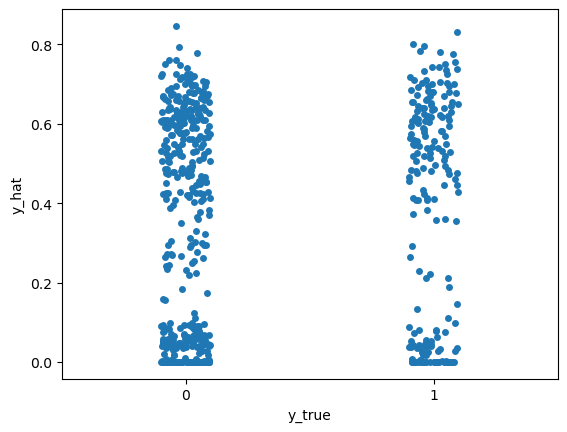

In [58]:
sns.stripplot(data=df_pred,
               x='y_true',
              y='y_hat'
               )

In [42]:
# Convert to numpy arrays
intercept = posterior_samples["intercept"].values  # shape (chains, draws)
beta_cov = posterior_samples["beta_cov"].values
beta_soft = posterior_samples["beta_soft"].values
beta_disc = posterior_samples["beta_disc"].values
beta_bq = posterior_samples["beta_bq"].values

# Stack into (n_samples, n_features)
n_chains = posterior_samples.chain.nunique()
n_draws = posterior_samples.draw.nunique()
n_samples = n_chains * n_draws

n_chains, n_draws

(4, 2000)

In [47]:
posterior_samples.query("chain==0 & draw==1")

,chain,draw,p_dim_0,beta_cov,beta_soft,beta_disc,beta_bq,intercept,p
613,0,1,0,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.033302
614,0,1,1,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.000015
615,0,1,2,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.065953
616,0,1,3,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.000018
617,0,1,4,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.664209
...,...,...,...,...,...,...,...,...,...
1221,0,1,608,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.000055
1222,0,1,609,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.584353
1223,0,1,610,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.000086
1224,0,1,611,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.663490


In [45]:
beta_cov

array([1.49046284, 1.49046284, 1.49046284, ..., 1.40227558, 1.40227558,
       1.40227558])

In [40]:
# stack
betas = np.column_stack([
                        beta_cov
                        beta_soft
                        beta_disc
                        beta_bq
                        ])  # shape (n_samples, 4)

# Compute logit and probability for each posterior draw
logit_p = intercept_flat[:, None] + betas @ X_new.T  # shape (n_samples, n_new)
p_pred = 1 / (1 + np.exp(-logit_p))

array([-2.54308829, -2.54308829, -2.54308829, ..., -2.78494931,
       -2.78494931, -2.78494931])

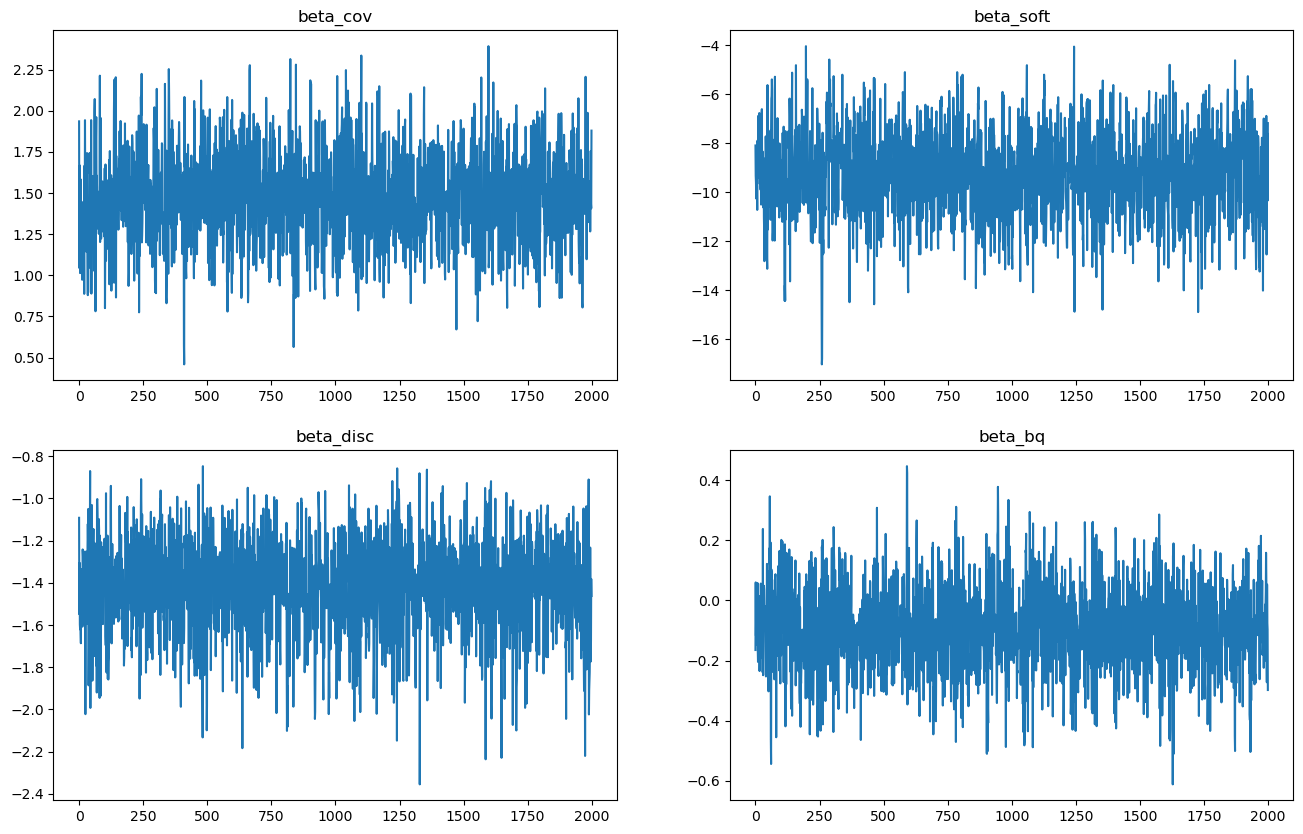

In [32]:
chain_num = 1

param_values = posterior_samples.columns[posterior_samples.columns.str.startswith('beta_')]

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

for i, param in enumerate(param_values):
    
    ax = axs[i]
    
    ax.plot(posterior_samples.query("chain==@chain_num")['draw'],
            posterior_samples.query("chain==@chain_num")[param],
           )
    
    ax.set_title(param)

In [6]:
def create_model_instance(X_train, y_train):
    
    with pm.Model() as model:
        # Priors for betas (directional expectations)
        beta_cov = pm.Normal("beta_cov", mu=0.5, sigma=2)       # coverage ratio (positive)
        beta_soft = pm.Normal("beta_soft", mu=-0.5, sigma=2)    # soft clips (negative)
        beta_disc = pm.Normal("beta_disc", mu=-0.5, sigma=2)    # discordant reads (negative)
        beta_bq = pm.Normal("beta_bq", mu=0.5, sigma=2)         # base quality (positive)

        # Intercept
        intercept = pm.Normal("intercept", mu=0, sigma=2)

        # Linear predictor (logit scale)
        logit_p = (
            intercept
            + beta_cov * X_train[:, 0]
            + beta_soft * X_train[:, 1]
            + beta_disc * X_train[:, 2]
            + beta_bq * X_train[:, 3]
        )

        # Probability via logistic link
        p = pm.Deterministic("p", pm.math.sigmoid(logit_p))

        # Likelihood
        y_obs = pm.Bernoulli("y_obs", p=p, observed=y_train)
        
    return model

        
model = create_model_instance(X_train, y_train)

Sampling: [y_obs]


Observed mean: 0.3556280587275693
Predictive mean (5%,50%,95%): [0.002    0.1675   0.200725]


<Axes: xlabel='y_obs'>

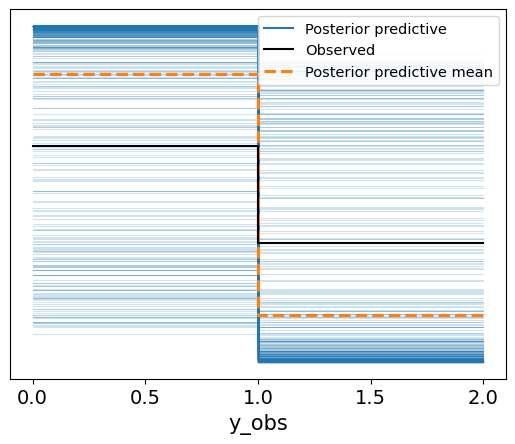

In [10]:
trace = az.from_netcdf("bayesian_model_trace.nc")

# run posterior predictive checks
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y_obs", "p"], random_seed=42)

# y_rep: shape (draws, n_obs) or (chains*draws, n_obs)
y_rep = ppc.posterior_predictive["y_obs"]
p_draws = ppc.posterior_predictive["p"]  # probabilities per draw

# Compare observed mean vs predictive distribution of means
obs_rate = y_train.mean()
ppc_means = y_rep.mean(axis=1)   # mean y across observations per draw
print("Observed mean:", obs_rate)
print("Predictive mean (5%,50%,95%):", np.percentile(ppc_means, [5,50,95]))
# az.plot_ppc(az.from_pymc3(posterior_predictive=ppc, model=model))
az.plot_ppc(ppc, num_pp_samples=613)

In [9]:
y_rep.mean(axis=1)

<xarray.DataArray 'y_obs' (chain: 4, y_obs_dim_0: 613)> Size: 20kB
array([[0.1755, 0.0025, 0.1805, ..., 0.009 , 0.188 , 0.199 ],
       [0.148 , 0.003 , 0.166 , ..., 0.009 , 0.159 , 0.1675],
       [0.144 , 0.0015, 0.148 , ..., 0.004 , 0.164 , 0.153 ],
       [0.168 , 0.0025, 0.1765, ..., 0.01  , 0.1825, 0.177 ]],
      shape=(4, 613))
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * y_obs_dim_0  (y_obs_dim_0) int64 5kB 0 1 2 3 4 5 ... 607 608 609 610 611 612